In [909]:
import os

if 'main_dir' in globals():
    os.chdir(main_dir)

import pandas as pd
from utils.load_config import load_exp_config, get_value_from_fields, get_df_historical_data
from utils.load_data import (
    get_df_from_datetime_range
    )
import numpy as np

# %matplotlib inline

if os.getcwd().endswith("notebooks"):
    main_dir = os.getcwd()
    os.chdir("..")

In [910]:
os.getuid()

1000

In [911]:
DECAY_RATE = 1

start_datetime_str = "2024-11-04 15-18-27"
end_datetime_str = "2024-11-05 08-00-00"

# end_datetime_str = start_datetime_str = "2024-11-04 14-38-04"
# end_datetime_str = start_datetime_str = "2024-10-31 13-46-21"
# end_datetime_str = start_datetime_str = "2024-11-06 11-00-44" # Error of unchanged observation
# end_datetime_str = start_datetime_str = "2024-11-06 12-08-58"

# contain large buffer and reset buffer [true, false]
start_datetime_str = "2024-11-06 12-08-58"
end_datetime_str = "2024-11-06 13-27-35"

# contain large buffer and reset buffer [true, false] with bugfix on robot pursuit
start_datetime_str = "2024-11-07 08-38-32"
end_datetime_str = "2024-11-07 10-41-32"

# end_datetime_str = start_datetime_str = "2024-11-07 11-31-51"
end_datetime_str = start_datetime_str = "2024-11-09 14-13-27"

# Full run at server
start_datetime_str = "2024-11-07 14-35-44"
end_datetime_str = "2024-11-08 04-58-17"

# Test
end_datetime_str = start_datetime_str = "2024-11-08 21-30-23"
end_datetime_str = start_datetime_str = "2024-11-10 22-47-07"
end_datetime_str = start_datetime_str = "2024-11-11 07-38-36"
# end_datetime_str = start_datetime_str = "2024-11-09 20-42-20"


# end_datetime_str = start_datetime_str = "2024-11-08 21-30-23"

# end_datetime_str = start_datetime_str = "2024-11-10 14-18-31"
# end_datetime_str = start_datetime_str = "2024-11-10 16-46-24"


# Full SAC run at server
# start_datetime_str = "2024-11-08 22-32-12"
# end_datetime_str = "2024-11-09 06-05-21"

# SAC with Pushing Object
end_datetime_str = start_datetime_str = "2024-11-11 09-14-40"
end_datetime_str = start_datetime_str = "2024-11-11 11-23-51"

# SAC Line Following
end_datetime_str = start_datetime_str = "2024-11-09 22-07-25"

df = get_df_from_datetime_range(start_datetime_str, 
                                end_datetime_str, 
                                decay_rate=DECAY_RATE,
                                max_iter=np.inf,
                                validity_check=False,
                                reload=False
                                )

end_datetime_str = start_datetime_str = "2024-11-11 09-14-40"
df_2 = get_df_from_datetime_range(start_datetime_str, 
                                end_datetime_str, 
                                decay_rate=DECAY_RATE,
                                max_iter=np.inf,
                                validity_check=False,
                                reload=False
                                )

df = pd.concat([df, df_2])

df.head()

,time,running_objective,current_value,current_undiscounted_value,episode_id,iteration_id,task_name,step_id,phase,exploration,...,Image pixel 1190,Image pixel 1191,Image pixel 1192,Image pixel 1193,Image pixel 1194,Image pixel 1195,Image pixel 1196,Image pixel 1197,Image pixel 1198,Image pixel 1199
0,0.000,0.489796,None,0.489796,1,1,circle_red,0,train,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.000,0.081633,None,0.571429,1,1,circle_red,1,train,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.165,0.000000,None,0.571429,1,1,circle_red,2,train,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.330,0.040816,None,0.612245,1,1,circle_red,3,train,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.495,0.000000,None,0.612245,1,1,circle_red,4,train,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [912]:
exp_config = df.exp_config.values[0]
df = df.reindex()
def extract_columns(row):
    scenario = row.exp_config["scenario"]["_target_"].split(".")[-1]
    is_reset_buffer = row.exp_config["scenario"]["reset_rb_each_task"]
    buffer_size = row.exp_config["scenario"]["buffer_size"]
    learning_starts = row.exp_config["scenario"]["learning_starts"]
    controller = "SAC" if "sac" in scenario.lower() else "TD3"
    category = scenario[:scenario.find(controller)]
    return category, controller, is_reset_buffer, buffer_size, learning_starts
    
    # return pd.Series(data=[category, controller, is_reset_buffer, buffer_size], 
    #                  index=["category", "controller", "is_reset_buffer", "buffer_size"])

tmp = df.apply(extract_columns, axis=1, result_type='expand')
# tmp = df.exp_config.apply(extract_columns)
tmp.columns = ["category", "controller", "is_reset_buffer", "buffer_size", "learning_starts"]
df = pd.concat([df, tmp], axis=1)

In [913]:
[c for c in df.columns if "pos" in c]

[]

In [914]:
pd.Series(tmp.iloc[0], index=["category", "controller", "is_reset_buffer", "buffer_size"])

category           LineFollowing
controller                   SAC
is_reset_buffer                 
buffer_size                16000
Name: 0, dtype: object

In [915]:
############################### Robot Pursuit is misisng ###############################
# group_df = df.groupby(["controller", "category", "task_name", "is_reset_buffer"]).last()
group_df = df.groupby(["controller", "category", "buffer_size"]).last()
group_df

time  running_objective current_value  \
controller category      buffer_size                                          
SAC        LineFollowing 16000        4.62           0.979592          None   
           PushingObject 16000        4.62           0.696133          None   

                                      current_undiscounted_value  episode_id  \
controller category      buffer_size                                           
SAC        LineFollowing 16000                         25.632653           1   
           PushingObject 16000                         26.395887           1   

                                      iteration_id      task_name  step_id  \
controller category      buffer_size                                         
SAC        LineFollowing 16000                 731  circle_yellow      119   
           PushingObject 16000                  84         yellow      626   

                                     phase  exploration  ...  \
controller category      buffer_size                     ...   
SAC        LineFollowing 16000        eval        False  ...   
           PushingObject 16000        eval        False  ...   

                                      Image pixel 1192  Image pixel 1193  \
controller category      buffer_size                                       
SAC        LineFollowing 16000                     NaN               NaN   
           PushingObject 16000                0.423529          0.423529   

                                      Image pixel 1194  Image pixel 1195  \
controller category      buffer_size                                       
SAC        LineFollowing 16000                     NaN               NaN   
           PushingObject 16000                0.423529          0.423529   

                                      Image pixel 1196  Image pixel 1197  \
controller category      buffer_size                                       
SAC        LineFollowing 16000                     NaN               NaN   
           PushingObject 16000                0.423529          0.423529   

                                      Image pixel 1198  Image pixel 1199  \
controller category      buffer_size                                       
SAC        LineFollowing 16000                     NaN               NaN   
           PushingObject 16000                0.423529          0.423529   

                                      is_reset_buffer  learning_starts  
controller category      buffer_size                                    
SAC        LineFollowing 16000                                     400  
           PushingObject 16000                   True             1000  

[2 rows x 1217 columns]

In [916]:
group_df.index.names, group_df.index[0]

(FrozenList(['controller', 'category', 'buffer_size']),
 ('SAC', 'LineFollowing', 16000))

In [917]:
"\t".join([f"{a}:{b}" for a, b in list(zip(group_df.index.names, group_df.index[0]))])
# list(zip(group_df.index.names, group_df.index[0]))
group_df.index

MultiIndex([('SAC', 'LineFollowing', 16000),
            ('SAC', 'PushingObject', 16000)],
           names=['controller', 'category', 'buffer_size'])

In [918]:
df = df.reset_index().set_index(group_df.index.names)
tmp_df = df.loc[group_df.index[0]]

In [919]:
from matplotlib import rc
# rc('font',**{'family':'sans-serif','sans-serif':['Helvelica']})
# for Palatino and other serif fonts use:
# rc('font',**{'family':'serif','serif':['Palatino']})
rc('text', usetex=False)

In [920]:
import matplotlib
print(matplotlib.matplotlib_fname())
matplotlib.__version__

/home/tcc/huyhoang/irlc_2025/regelum-playground-iclr/venv/lib/python3.10/site-packages/matplotlib/mpl-data/matplotlibrc


'3.9.2'

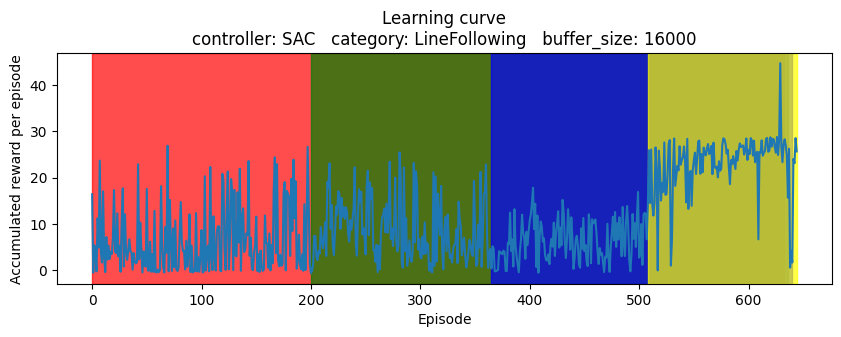

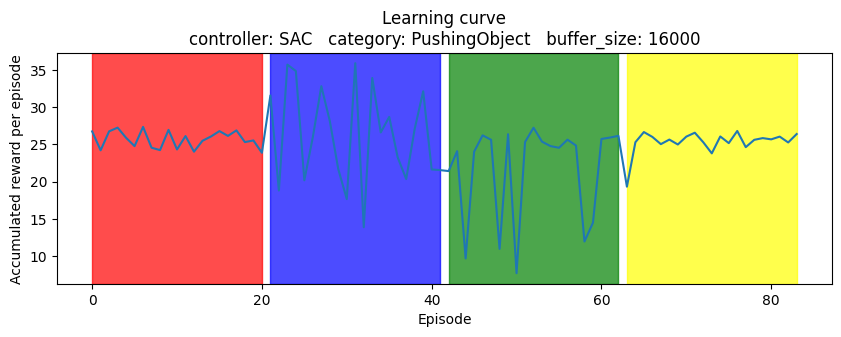

In [921]:
import matplotlib.pyplot as plt
# import matplotlib
# %matplotlib inline

def plot_learning_curve(index, index_names, df, title="Learning curve"):
    fig, ax = plt.subplots(figsize=(10,3))

    df = df.reset_index().set_index(index_names)
    tmp_df = df.loc[index]

    # Filter exploration actions
    tmp_df = tmp_df.loc[:, ["iteration_id", "step_id", "task_name", "current_undiscounted_value", "learning_starts", "phase"]]
    tmp_df = tmp_df[np.invert(np.logical_and(tmp_df.phase == "train", tmp_df.step_id <= tmp_df.learning_starts))]
    tmp_group_df = tmp_df.groupby("iteration_id")

    tmp_group_df = tmp_group_df.aggregate({
        "current_undiscounted_value": "last", 
        "task_name": "last",
        "step_id": "last"
        })
    
    # Re-assign index for ploting
    tmp_group_df = tmp_group_df.reset_index()
    tmp_group_df.iteration_id = tmp_group_df.reset_index().index
    tmp_group_df = tmp_group_df.set_index("iteration_id")

    tmp_group_df.plot(y="current_undiscounted_value", ax=ax)

    colors = ["red", "blue", "green", "yellow"]
    for t in tmp_group_df.task_name.unique():
        for c in colors:
            if c in t.lower():
                break

        tmp = tmp_group_df.reset_index().set_index("task_name").loc[t]
        ax.axvspan(tmp.iteration_id.values[0], tmp.iteration_id.values[-1], alpha=0.7, color=c)

    ax.set_xlabel('Episode')
    ax.set_ylabel('Accumulated reward per episode')
    ax.set_title(
        f'{title}\n' + 
        "   ".join([f"{a}: {b}" for a, b in list(zip(index_names, index))])
    )
    legend = ax.legend()
    legend.remove()


for id in group_df.index:
    plot_learning_curve(id, group_df.index.names, df)
    
# plot_learning_curve(group_df.index[1], group_df.index.names, df)
# plot_learning_curve(('SAC', 'LineFollowing', True), group_df.index.names, df)
# plot_learning_curve(('TD3', 'LineFollowing', False), group_df.index.names, df)
# plt.show()

In [922]:
df = df.reset_index()
df

,controller,category,buffer_size,index,time,running_objective,current_value,current_undiscounted_value,episode_id,iteration_id,...,Image pixel 1192,Image pixel 1193,Image pixel 1194,Image pixel 1195,Image pixel 1196,Image pixel 1197,Image pixel 1198,Image pixel 1199,is_reset_buffer,learning_starts
0,SAC,LineFollowing,16000,0,0.000,0.489796,None,0.489796,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,400
1,SAC,LineFollowing,16000,1,0.000,0.081633,None,0.571429,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,400
2,SAC,LineFollowing,16000,2,0.165,0.000000,None,0.571429,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,400
3,SAC,LineFollowing,16000,3,0.330,0.040816,None,0.612245,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,400
4,SAC,LineFollowing,16000,4,0.495,0.000000,None,0.612245,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18860,SAC,PushingObject,16000,25,3.960,0.850000,None,22.954210,1,84,...,0.423529,0.423529,0.423529,0.423529,0.423529,0.423529,0.423529,0.423529,True,1000
18861,SAC,PushingObject,16000,26,4.125,0.950000,None,23.904210,1,84,...,0.423529,0.423529,0.423529,0.423529,0.423529,0.423529,0.423529,0.423529,True,1000
18862,SAC,PushingObject,16000,27,4.290,0.845545,None,24.749754,1,84,...,0.423529,0.423529,0.423529,0.423529,0.423529,0.423529,0.423529,0.423529,True,1000
18863,SAC,PushingObject,16000,28,4.455,0.950000,None,25.699754,1,84,...,0.423529,0.423529,0.423529,0.423529,0.423529,0.423529,0.423529,0.423529,True,1000


In [923]:
df.head()

,controller,category,buffer_size,index,time,running_objective,current_value,current_undiscounted_value,episode_id,iteration_id,...,Image pixel 1192,Image pixel 1193,Image pixel 1194,Image pixel 1195,Image pixel 1196,Image pixel 1197,Image pixel 1198,Image pixel 1199,is_reset_buffer,learning_starts
0,SAC,LineFollowing,16000,0,0.000,0.489796,None,0.489796,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,400
1,SAC,LineFollowing,16000,1,0.000,0.081633,None,0.571429,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,400
2,SAC,LineFollowing,16000,2,0.165,0.000000,None,0.571429,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,400
3,SAC,LineFollowing,16000,3,0.330,0.040816,None,0.612245,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,400
4,SAC,LineFollowing,16000,4,0.495,0.000000,None,0.612245,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,400


In [924]:
def postprocess_linefollowing(df):
    if not df.index.is_integer():
        df = df.reset_index()

    df["catch_the_line"] = df.running_objective.apply(lambda x: x > 0.7)
    return df

In [925]:
df = postprocess_linefollowing(df)

analyse_group_df = df[df.phase == "eval"].reset_index().groupby(["task_name", "iteration_id"])

if "catch_the_line" in df.columns:
    agg = dict.fromkeys(df.columns.difference(['catch_the_line', "task_name", "iteration_id"]), 'last')
    agg['catch_the_line'] = 'sum'

    analyse_group_df = analyse_group_df.agg(agg)
else:
    analyse_group_df = analyse_group_df.last()

analyse_group_df

/tmp/ipykernel_333031/3626384526.py:2: FutureWarning: RangeIndex.is_integer is deprecated. Use pandas.api.types.is_integer_dtype instead.
  if not df.index.is_integer():


Angular Velocity [rad/s]  Image pixel 0  \
task_name iteration_id                                            
blue      22                           -0.000719       0.854902   
          23                           -0.017046       0.854902   
          24                            1.038682       0.286275   
          25                            0.967886       0.854902   
          26                           -1.108392       0.854902   
...                                          ...            ...   
yellow    80                            1.067270       0.749020   
          81                            1.149175       0.854902   
          82                            0.895054       0.854902   
          83                           -1.456003       0.749020   
          84                            1.458153       0.749020   

                        Image pixel 1  Image pixel 10  Image pixel 100  \
task_name iteration_id                                                   
blue      22                 0.854902        0.286275         0.286275   
          23                 0.854902        0.854902         0.854902   
          24                 0.286275        0.286275         0.286275   
          25                 0.854902        0.854902         0.286275   
          26                 0.854902        0.854902         0.854902   
...                               ...             ...              ...   
yellow    80                 0.749020        0.749020         0.749020   
          81                 0.854902        0.854902         0.749020   
          82                 0.854902        0.854902         0.854902   
          83                 0.749020        0.749020         0.854902   
          84                 0.749020        0.749020         0.749020   

                        Image pixel 1000  Image pixel 1001  Image pixel 1002  \
task_name iteration_id                                                         
blue      22                    0.427451          0.427451          0.427451   
          23                    0.427451          0.427451          0.427451   
          24                    0.286275          0.749020          0.286275   
          25                    0.427451          0.427451          0.427451   
          26                    0.427451          0.427451          0.427451   
...                                  ...               ...               ...   
yellow    80                    0.427451          0.427451          0.427451   
          81                    0.427451          0.427451          0.427451   
          82                    0.427451          0.427451          0.427451   
          83                    0.427451          0.427451          0.427451   
          84                    0.427451          0.427451          0.427451   

                        Image pixel 1003  Image pixel 1004  ...  \
task_name iteration_id                                      ...   
blue      22                    0.427451          0.427451  ...   
          23                    0.427451          0.427451  ...   
          24                    0.286275          0.749020  ...   
          25                    0.427451          0.427451  ...   
          26                    0.427451          0.427451  ...   
...                                  ...               ...  ...   
yellow    80                    0.427451          0.427451  ...   
          81                    0.427451          0.427451  ...   
          82                    0.427451          0.427451  ...   
          83                    0.427451          0.427451  ...   
          84                    0.427451          0.427451  ...   

                                                          experiment_path  \
task_name iteration_id                                                      
blue      22            /home/tcc/huyhoang/irlc_2025/regelum-playgroun...   
          23            /home/tcc/huyhoang/ir

In [ ]:
df = postprocess_linefollowing(df)

if "eval" in df.phase.unique():
    analyse_group_df = df[df.phase == "eval"].reset_index().groupby(["task_name", "iteration_id"])

    if "catch_the_line" in df.columns:
        agg = dict.fromkeys(df.columns.difference(['catch_the_line', "task_name", "iteration_id"]), 'last')
        agg['catch_the_line'] = 'sum'

        analyse_group_df = analyse_group_df.agg(agg)
    else:
        analyse_group_df = analyse_group_df.last()

    def is_solved_task(row):
        if row.category == "LineFollowing":
            return row.catch_the_line > 25

        if row.category == "PushingObject":
            if row.task_name in ["blue", "yellow"]:
                return row.running_objective == 10
            
            if row.task_name in ["red", "green"]:
                return row.running_objective != -10

        return False

    def aggregate_function(series):
        sucess = np.sum(series)
        total = series.count()
        return "{:02.0f} / {:02.0f} = {:03.2f}".format(sucess, total, np.round(sucess / total, 2))

    analyse_group_df = analyse_group_df.reset_index()
    analyse_group_df["completion"] = analyse_group_df.apply(is_solved_task, axis=1)
    # analyse_group_df = analyse_group_df.set_index(['controller', 'category', 'buffer_size'])

    pivot_table = pd.pivot_table(
        analyse_group_df.reset_index(), 
        columns=['controller', 'buffer_size'],
        index=["category", "task_name"], 
        values="completion", aggfunc=aggregate_function
    )
    
else:
    pivot_table = None

pivot_table

/tmp/ipykernel_333031/3626384526.py:2: FutureWarning: RangeIndex.is_integer is deprecated. Use pandas.api.types.is_integer_dtype instead.
  if not df.index.is_integer():


controller                              SAC
buffer_size                           16000
category      task_name                    
LineFollowing circle_blue    01 / 04 = 0.25
              circle_green   03 / 04 = 0.75
              circle_red     02 / 04 = 0.50
              circle_yellow  01 / 04 = 0.25
PushingObject blue           12 / 21 = 0.57
              green          16 / 21 = 0.76
              red            21 / 21 = 1.00
              yellow         00 / 21 = 0.00

In [892]:
analyse_group_df.set_index(["task_name", "iteration_id"]).loc[:, ["catch_the_line"]]

catch_the_line
task_name iteration_id                
blue      22                        23
          23                        21
          24                        28
          25                        27
          26                        22
...                                ...
yellow    80                        25
          81                        27
          82                        28
          83                        23
          84                        27

[100 rows x 1 columns]

,step_id,task_name,current_undiscounted_value,learning_starts,phase
iteration_id,,,,,
0,29,red,26.749010,1000,eval
1,59,red,24.204368,1000,eval
2,89,red,26.757938,1000,eval
3,119,red,27.256125,1000,eval
4,149,red,25.888462,1000,eval
...,...,...,...,...,...
660,119,circle_blue,1.714286,400,eval
661,29,circle_yellow,24.000000,400,eval
662,59,circle_yellow,23.102041,400,eval


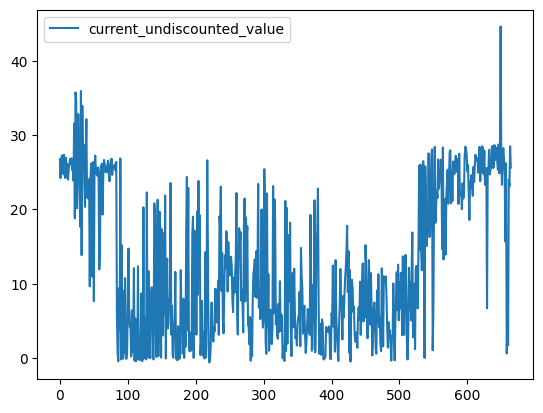

In [893]:
tmp_df = df.loc[:, ["iteration_id", "step_id", "task_name", "current_undiscounted_value", "learning_starts", "phase"]]
tmp_df = tmp_df[np.invert(np.logical_and(tmp_df.phase == "train", tmp_df.step_id <= tmp_df.learning_starts))]
g = tmp_df.groupby("iteration_id").last()
g = g.reset_index()
g.iteration_id = g.reset_index().index
g.plot(y="current_undiscounted_value")
g.set_index("iteration_id")

In [894]:
# df = df.reset_index().set_index(["controller", "category", "buffer_size", "task_name"])
# df[df.running_objective == 10].loc[['SAC']]

<Axes: xlabel='iteration_id'>

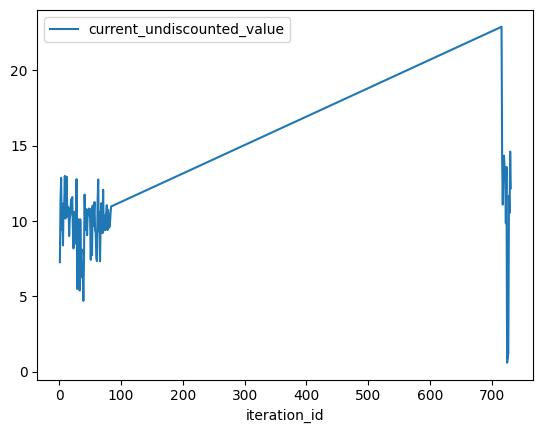

In [895]:
df = df.reset_index().set_index(["controller", "category", "buffer_size", "task_name"])
df = df.reset_index().set_index(group_df.index.names)
tmp_df = df.loc[group_df.index]

tmp_group_df = tmp_df.loc[:, ["iteration_id", "step_id", "task_name", "current_undiscounted_value", "phase"]].groupby("iteration_id")
tmp_group_df = tmp_group_df.aggregate({
    "current_undiscounted_value": "mean", 
    "task_name": "last",
    "step_id": "last",
    "phase": "last"
    })
tmp_group_df[tmp_group_df.phase=="eval"].plot(y="current_undiscounted_value")

/home/tcc/huyhoang/irlc_2025/regelum-playground-iclr/venv/lib/python3.10/site-packages/pandas/plotting/_matplotlib/core.py:580: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = self.plt.figure(figsize=self.figsize)


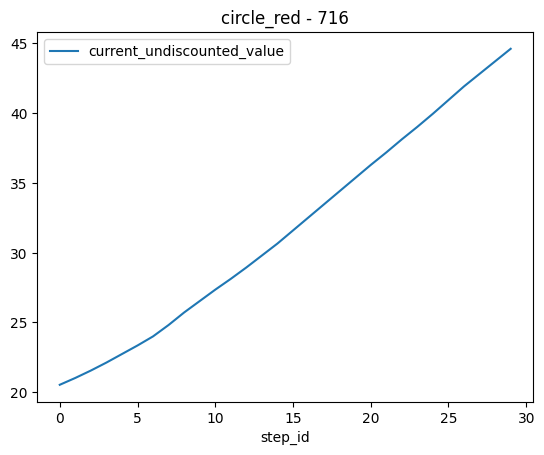

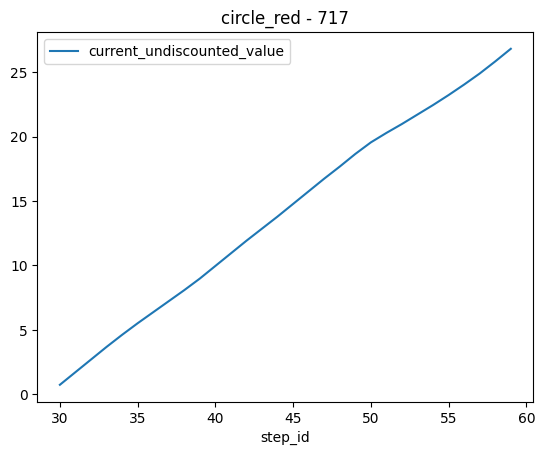

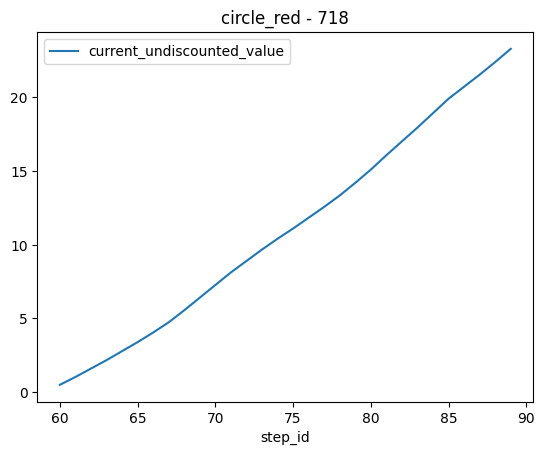

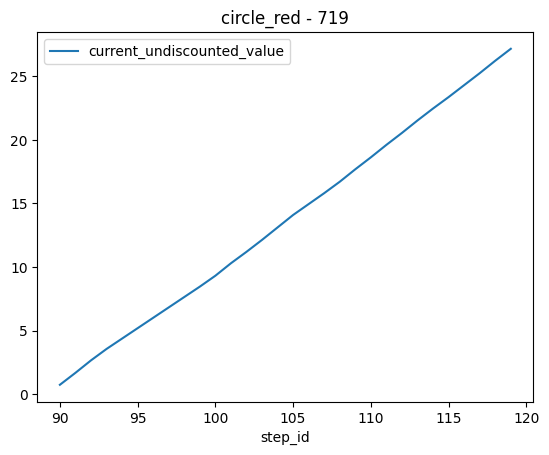

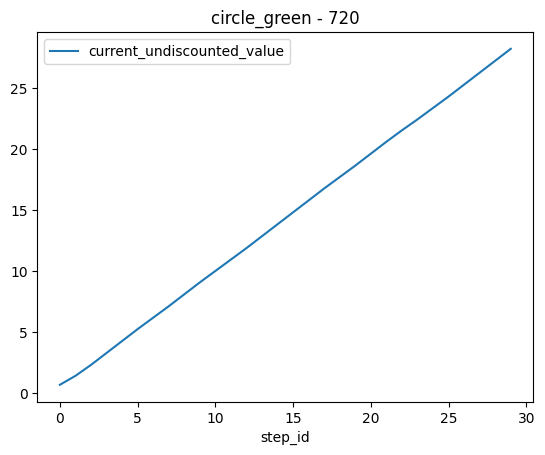

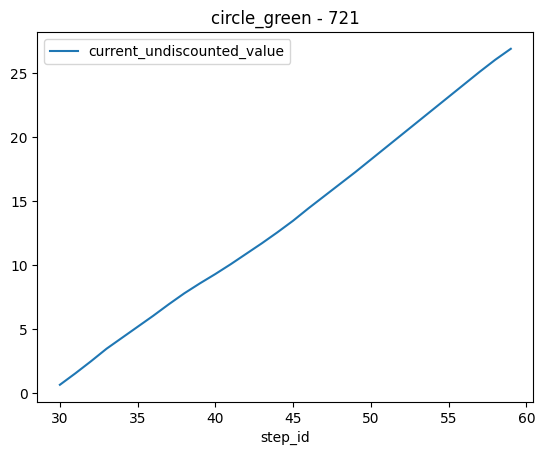

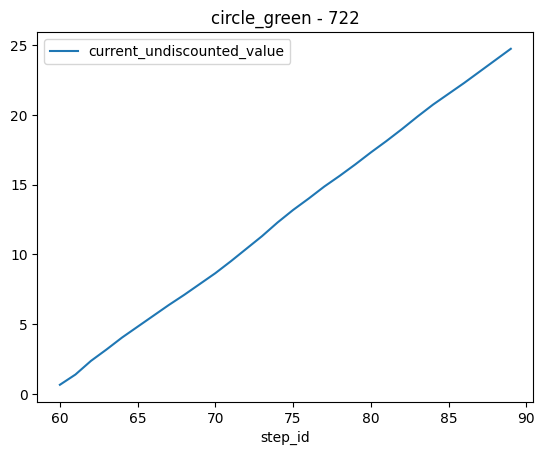

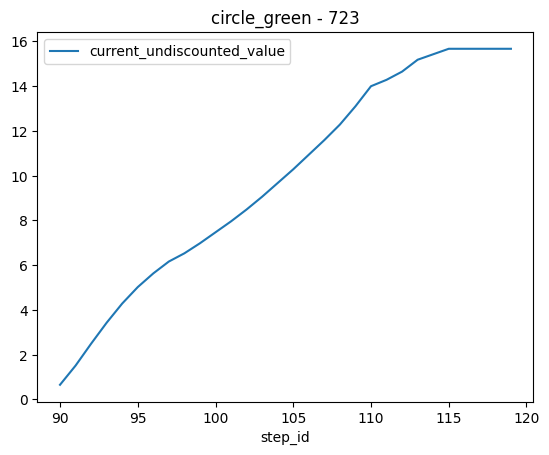

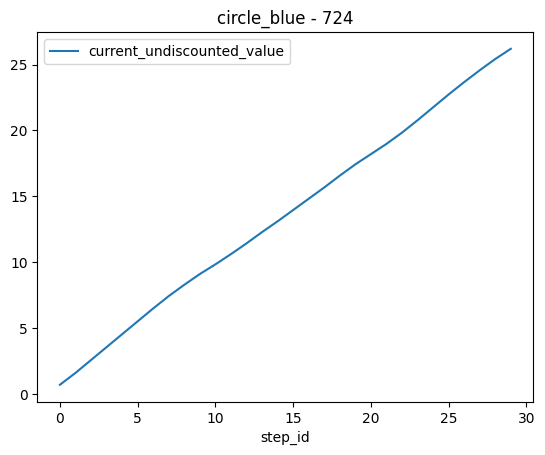

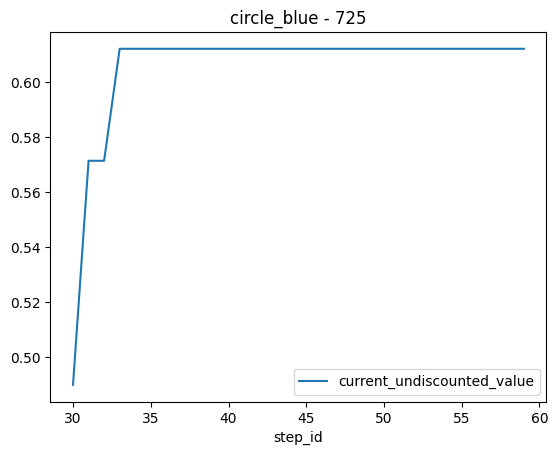

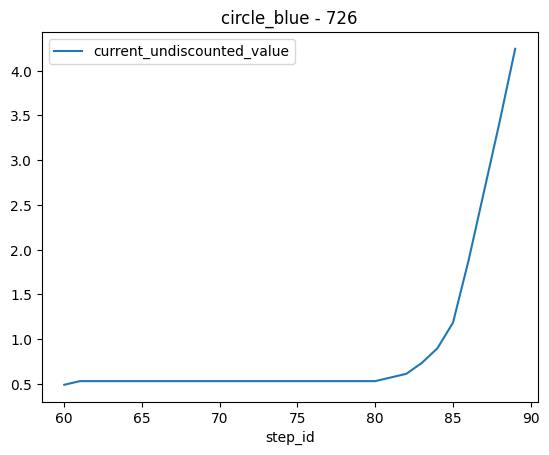

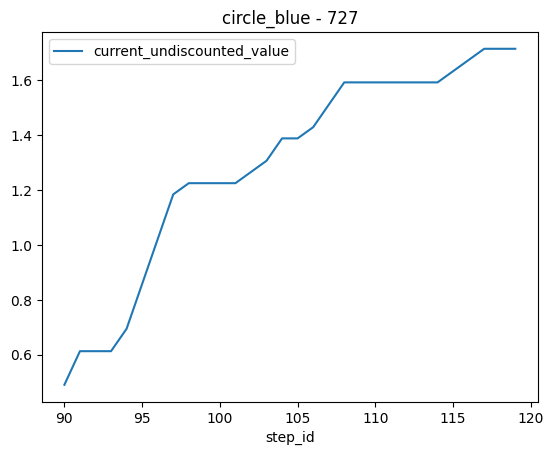

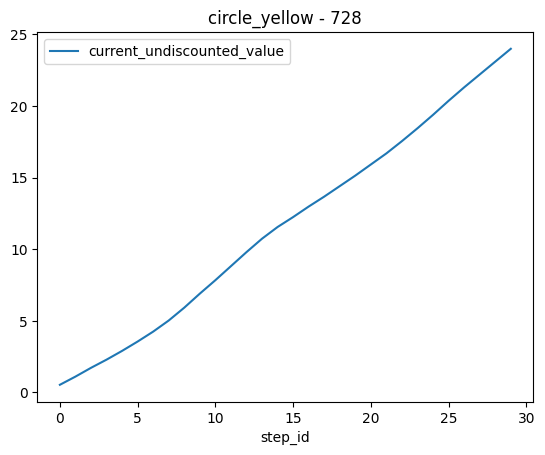

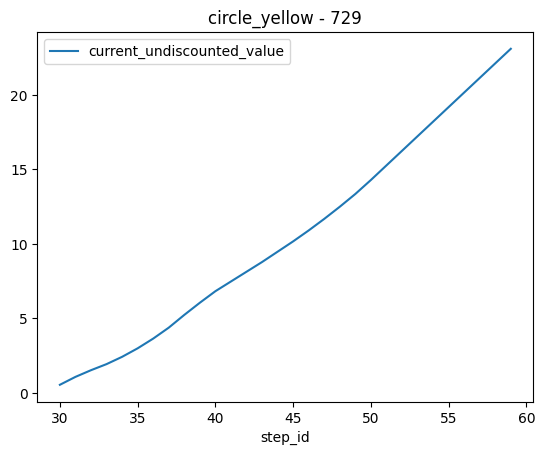

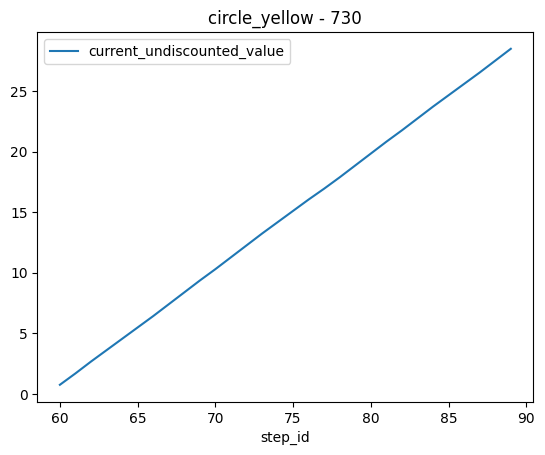

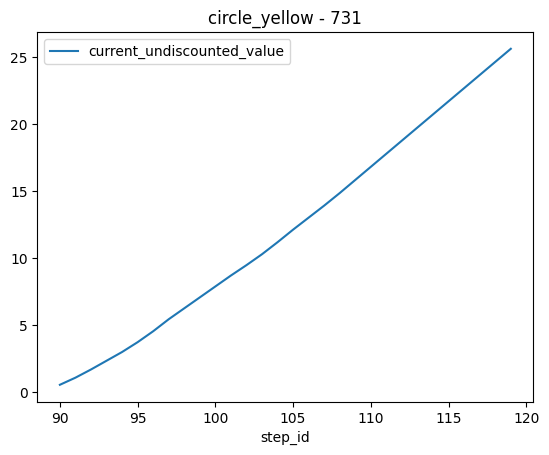

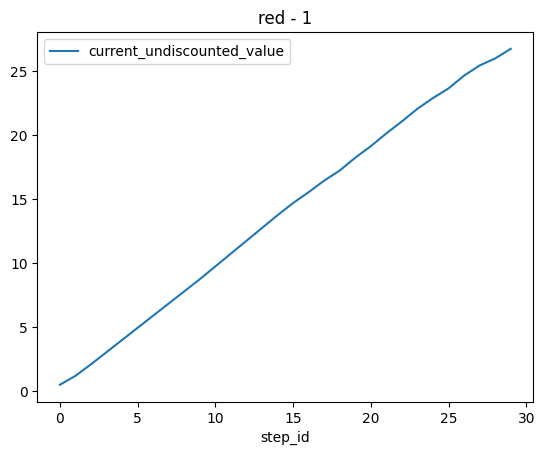

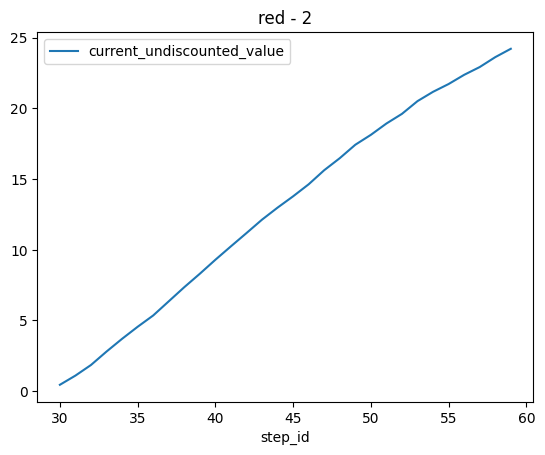

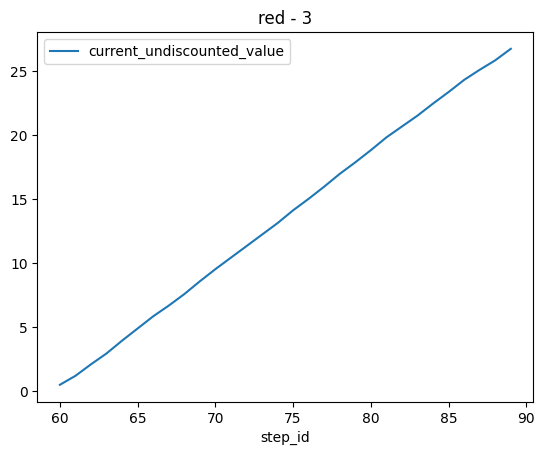

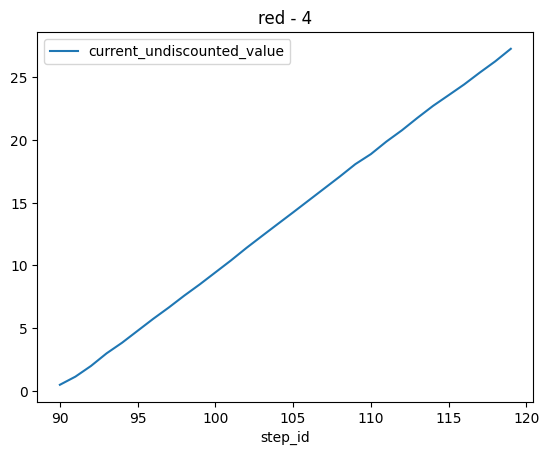

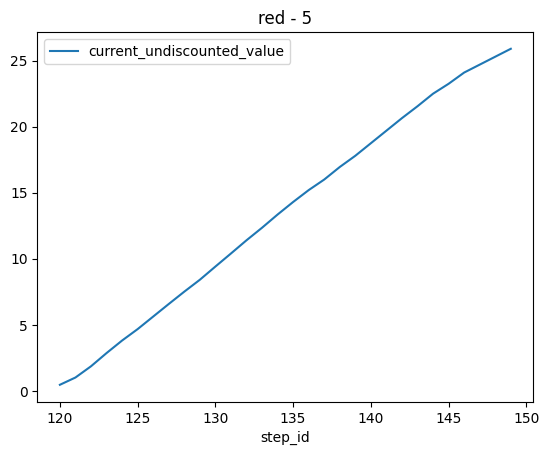

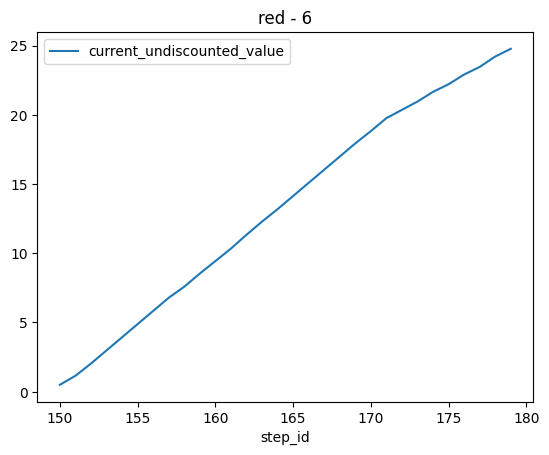

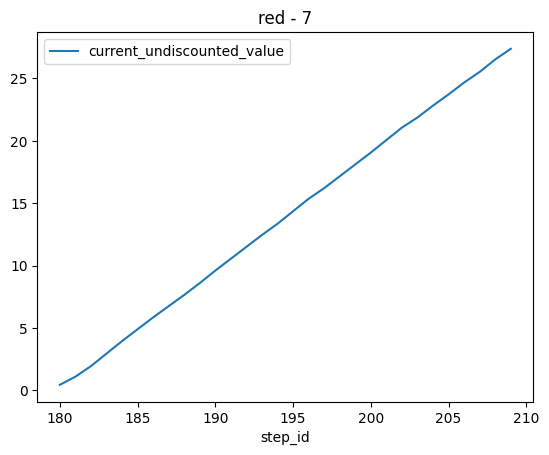

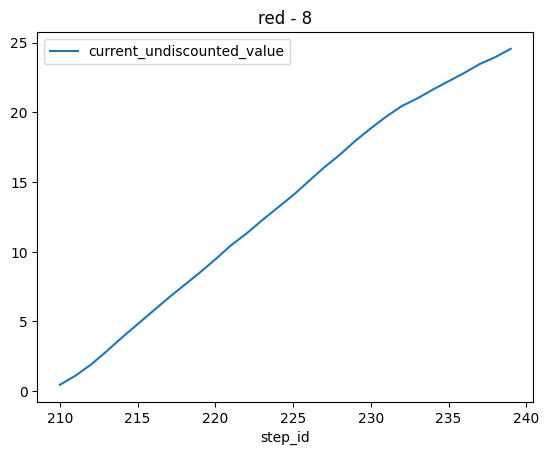

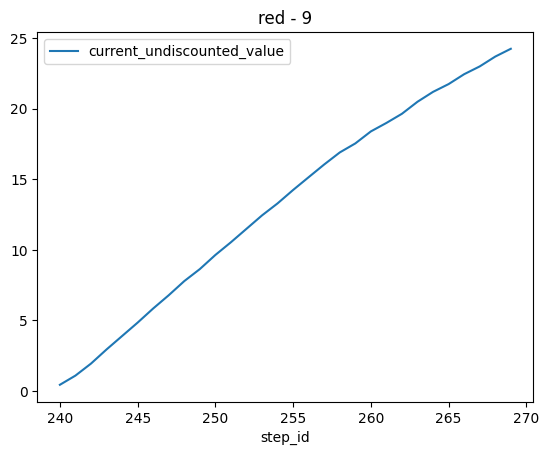

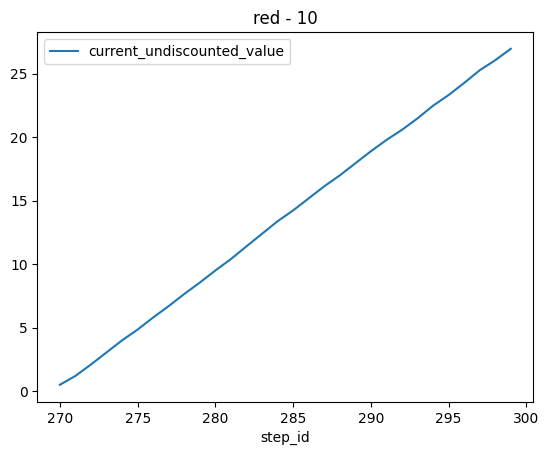

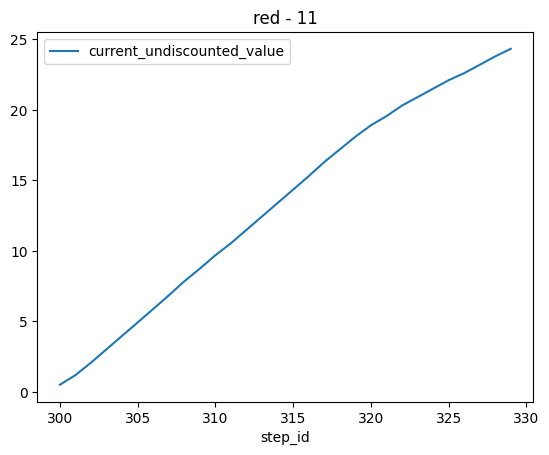

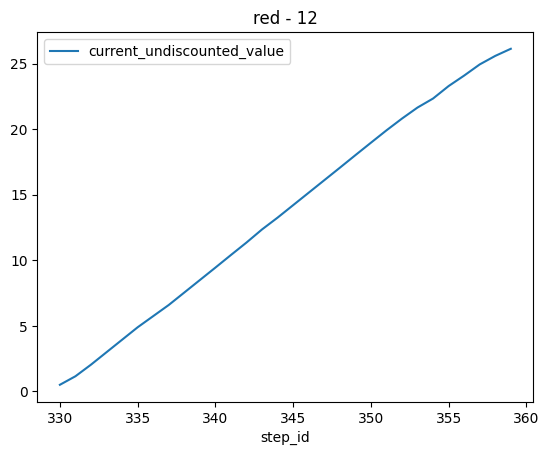

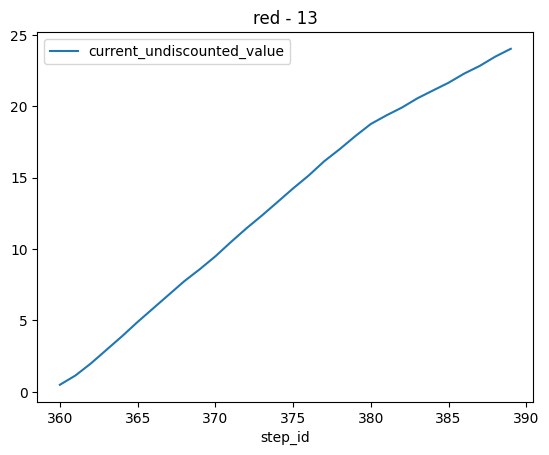

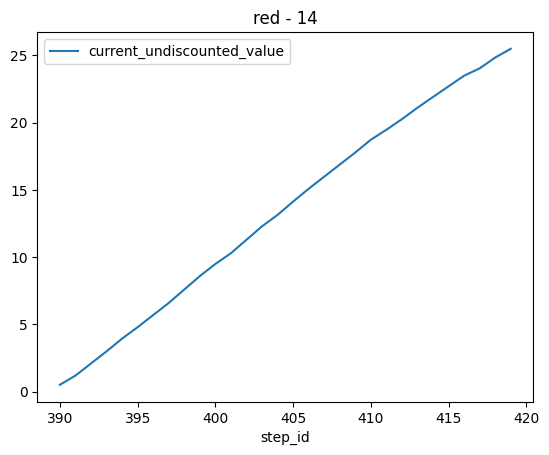

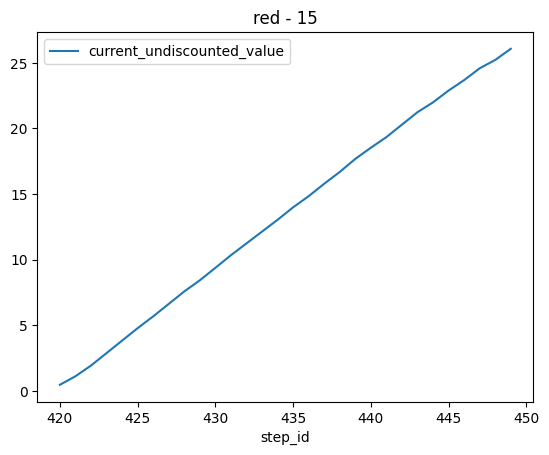

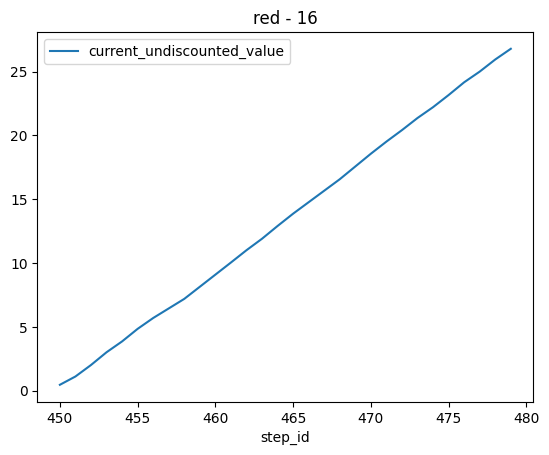

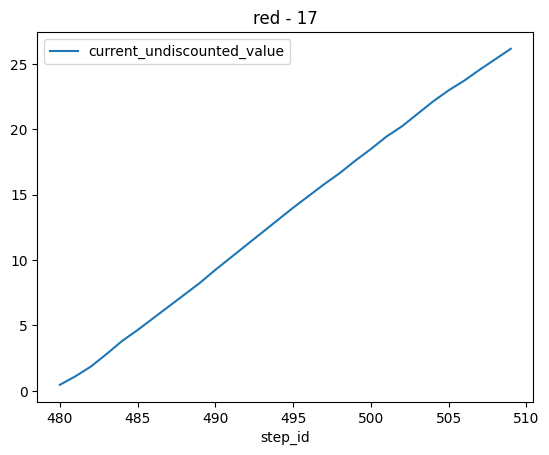

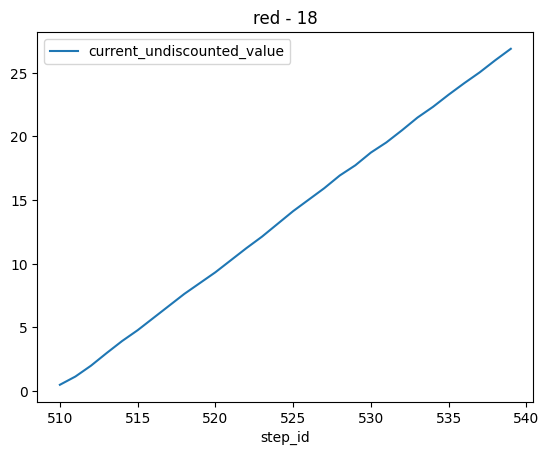

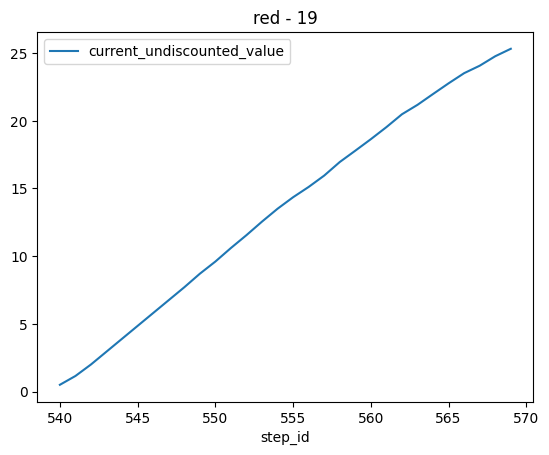

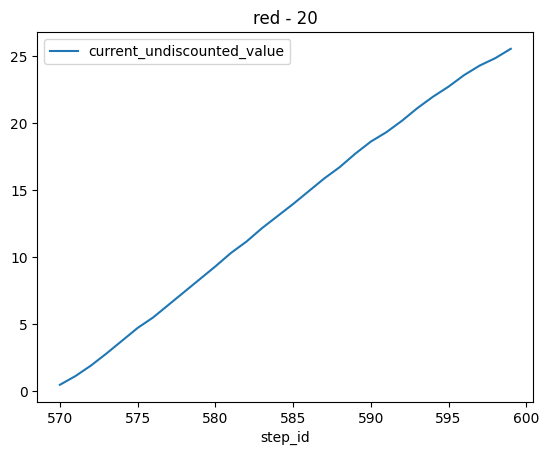

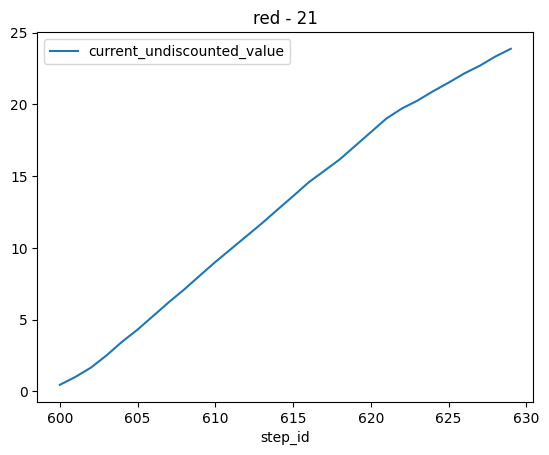

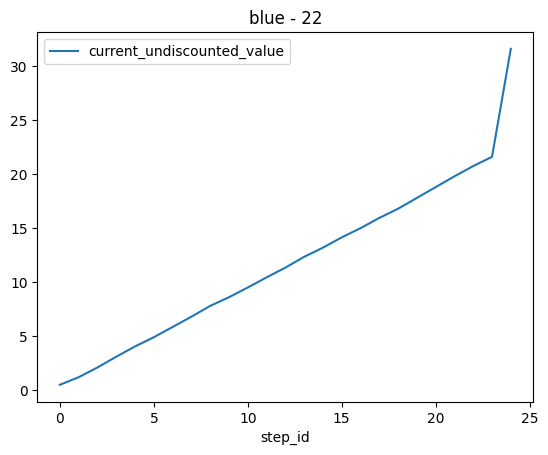

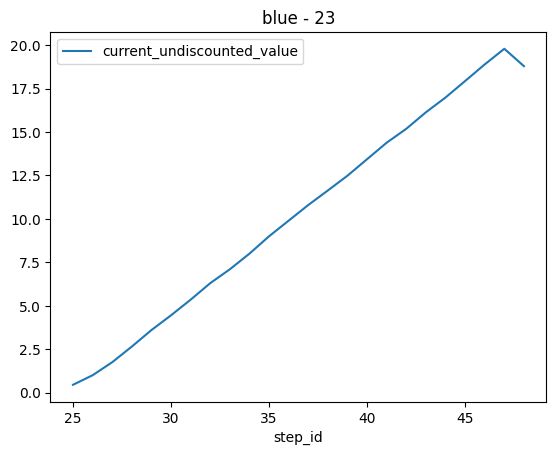

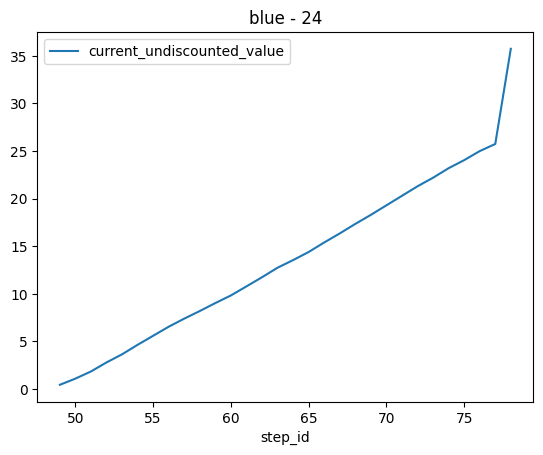

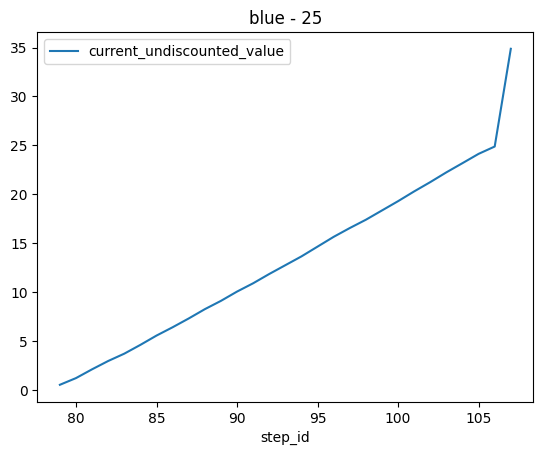

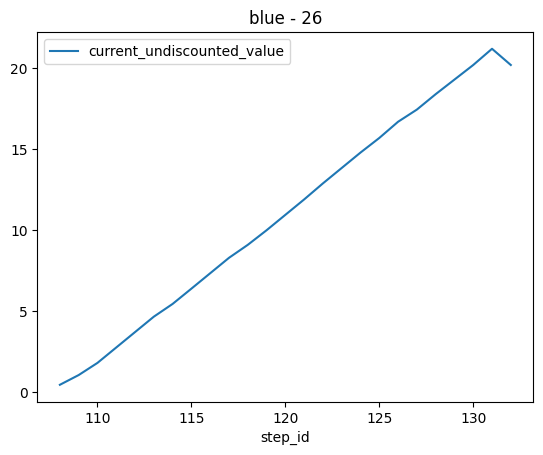

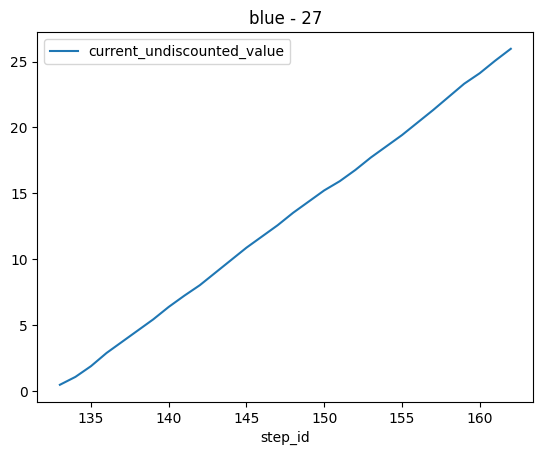

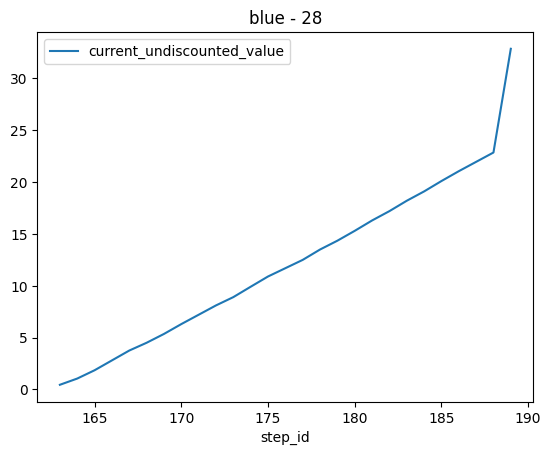

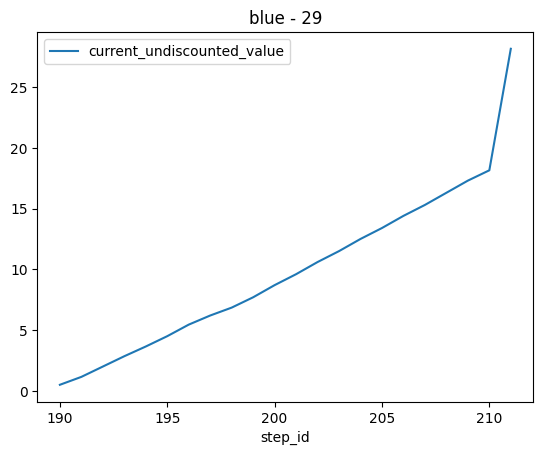

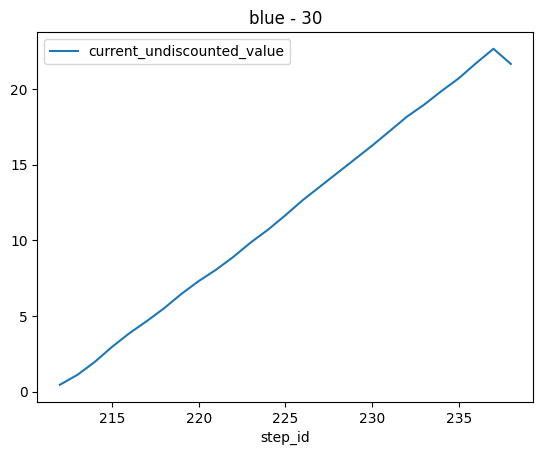

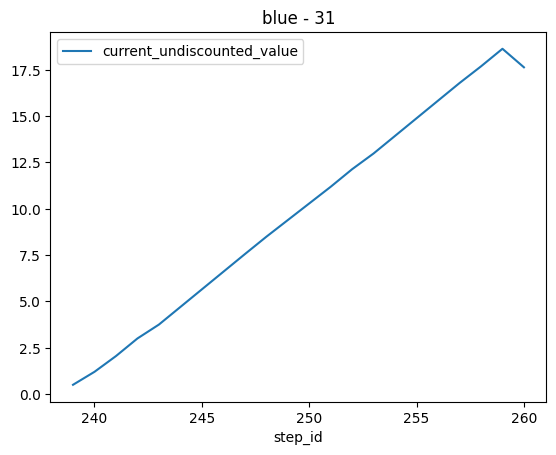

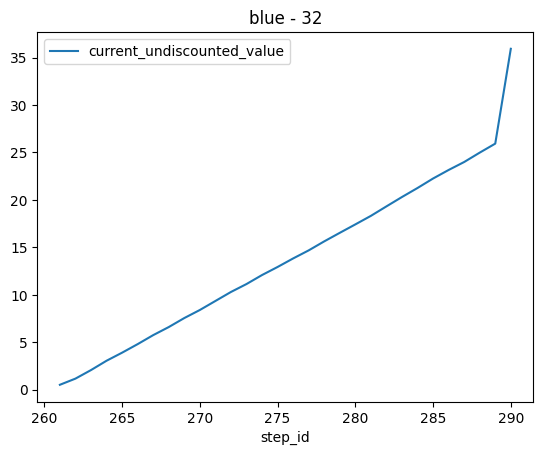

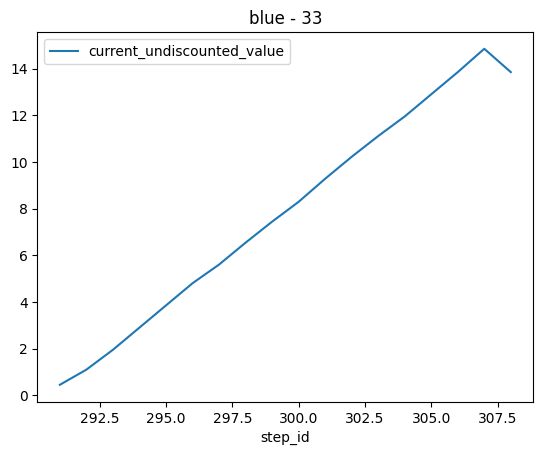

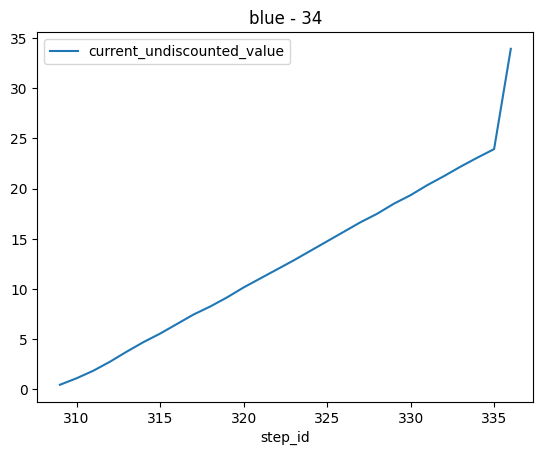

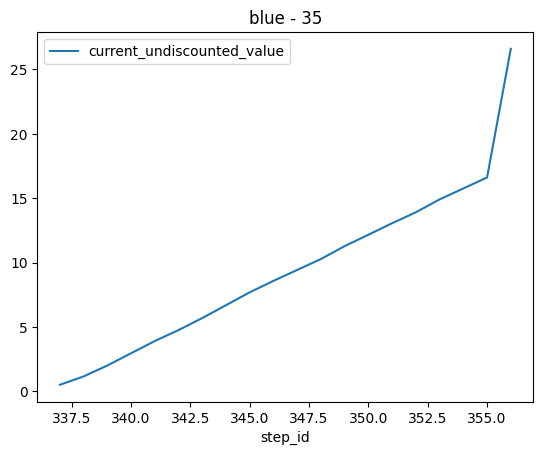

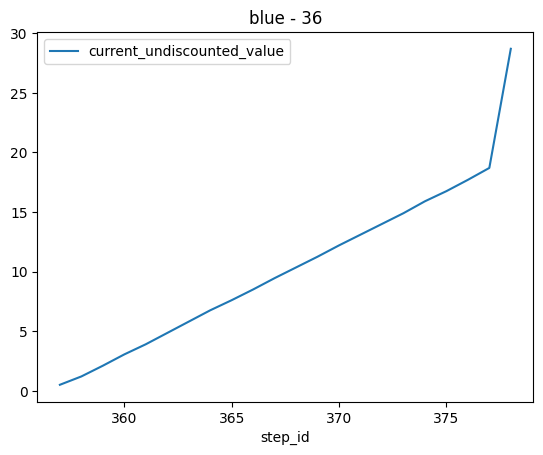

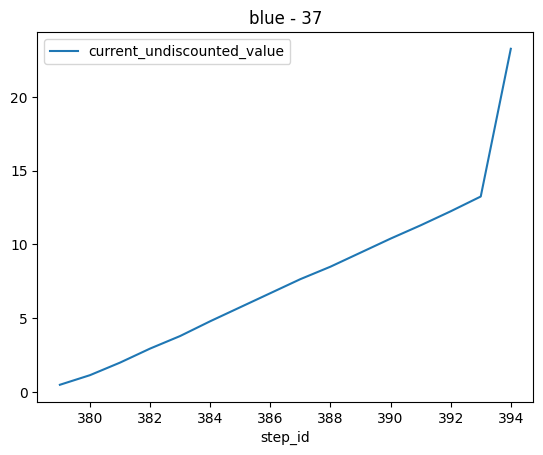

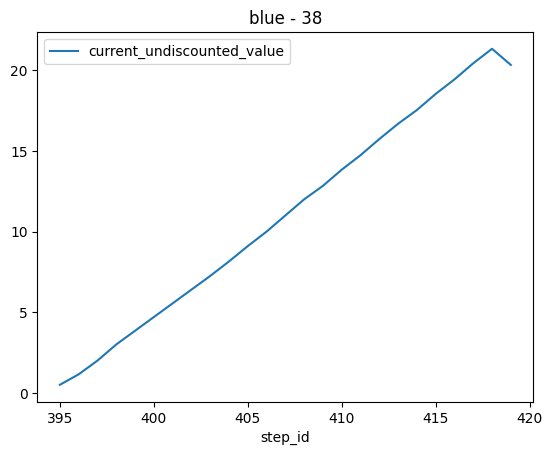

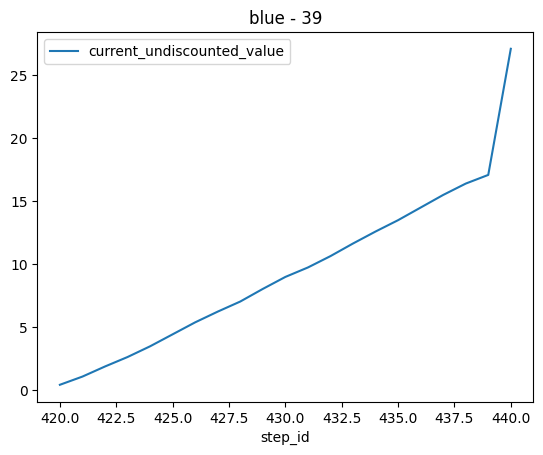

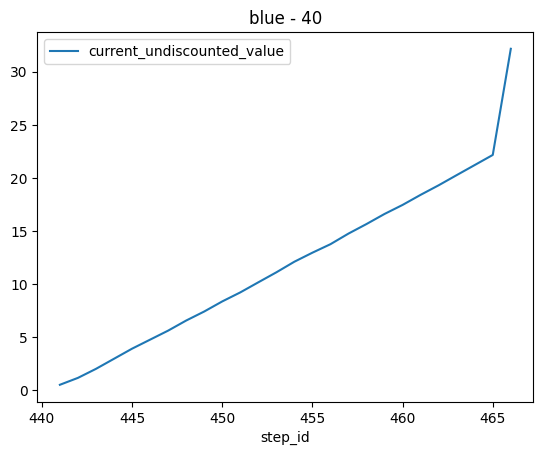

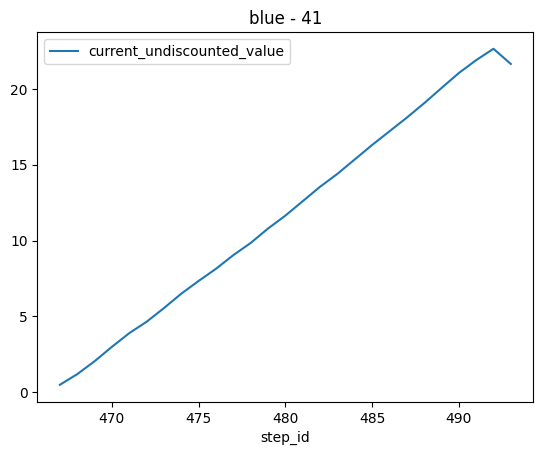

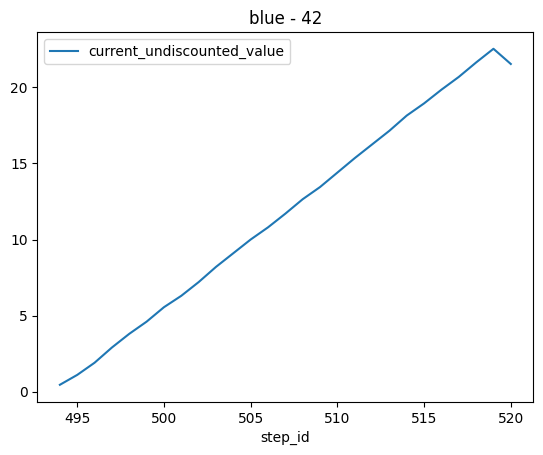

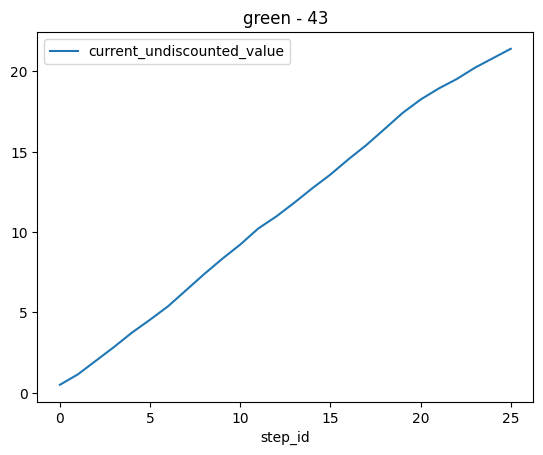

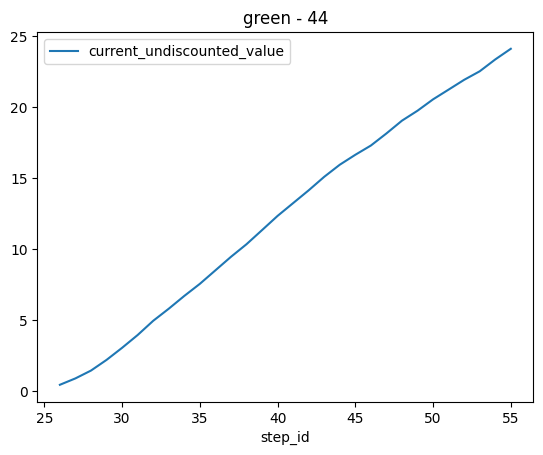

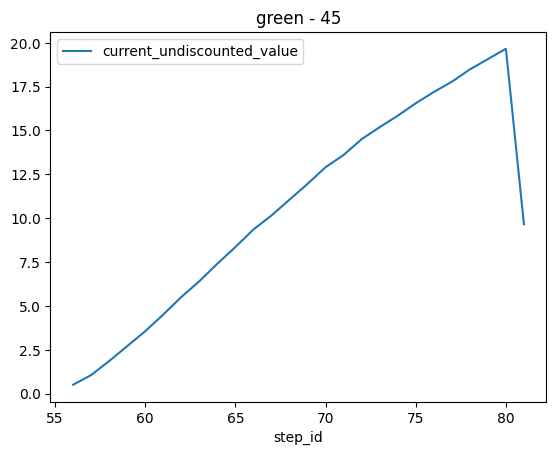

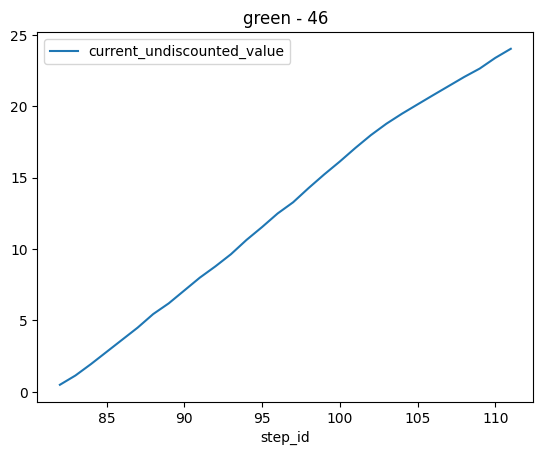

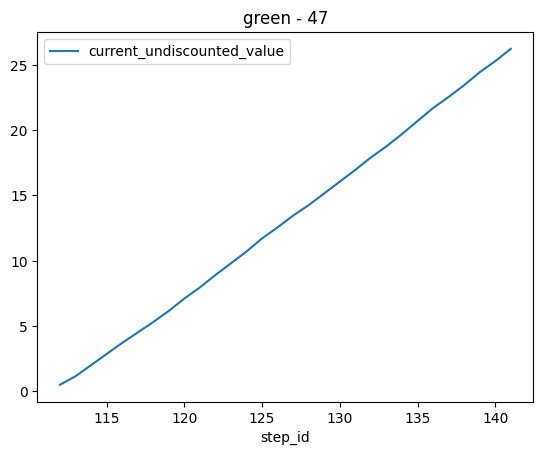

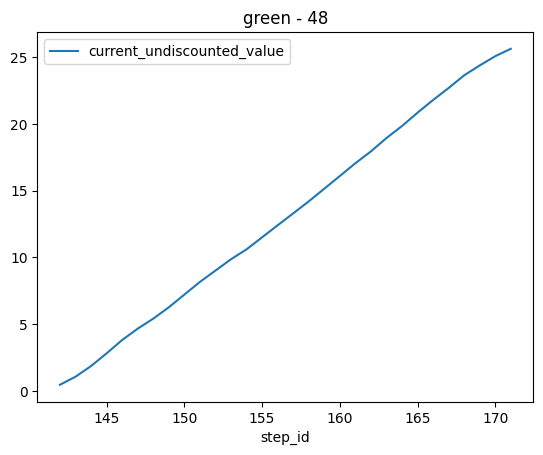

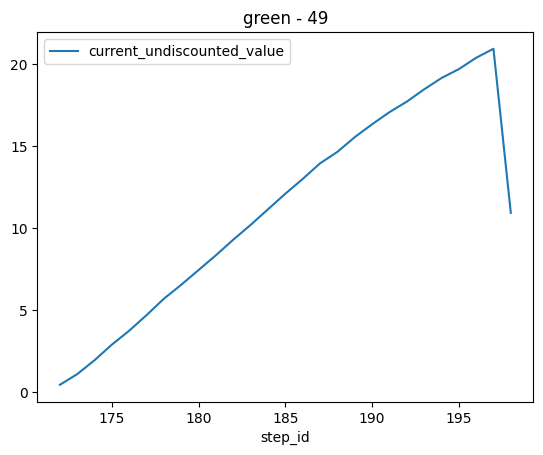

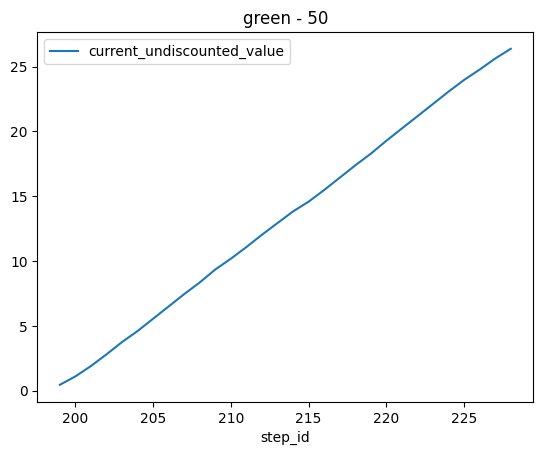

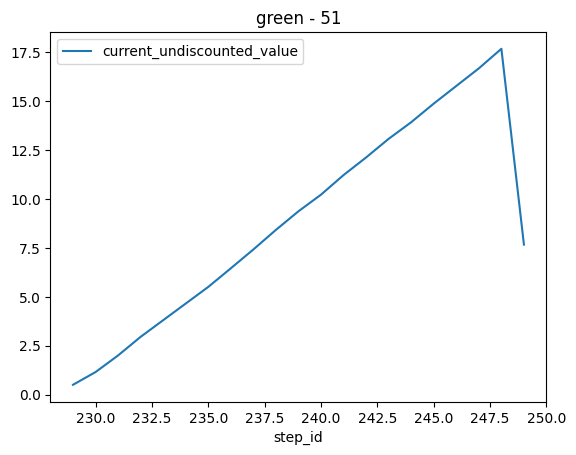

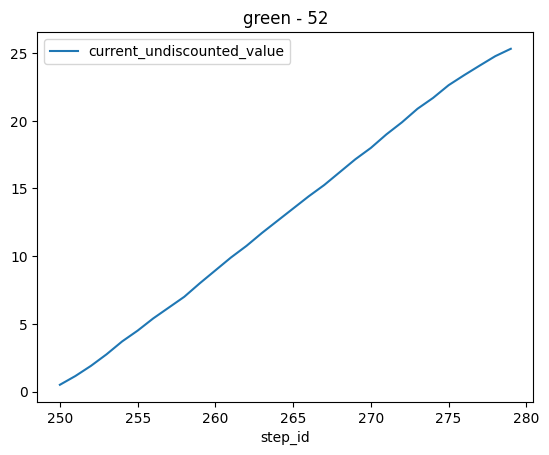

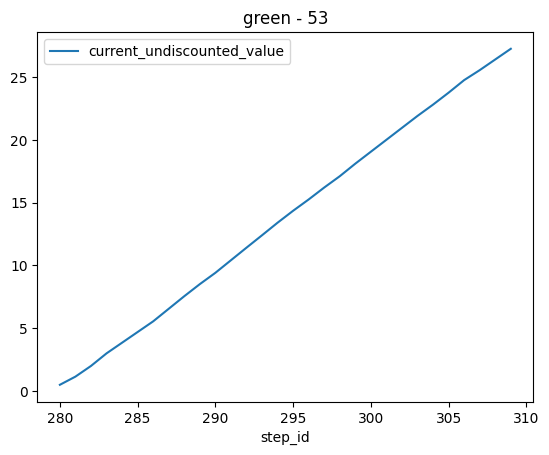

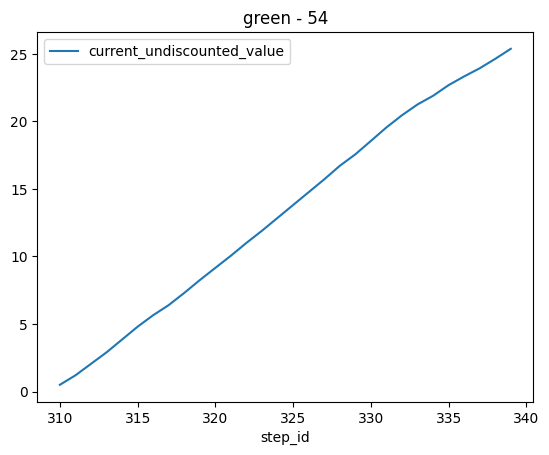

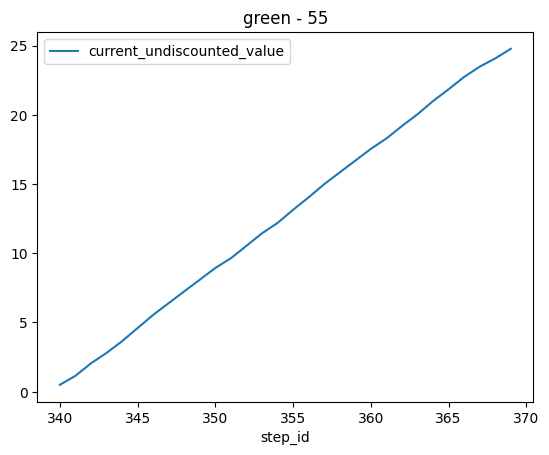

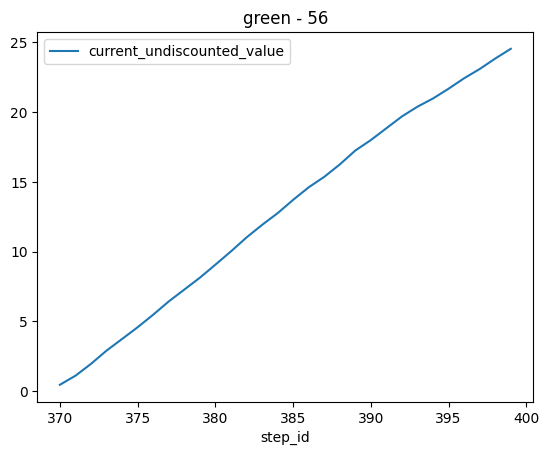

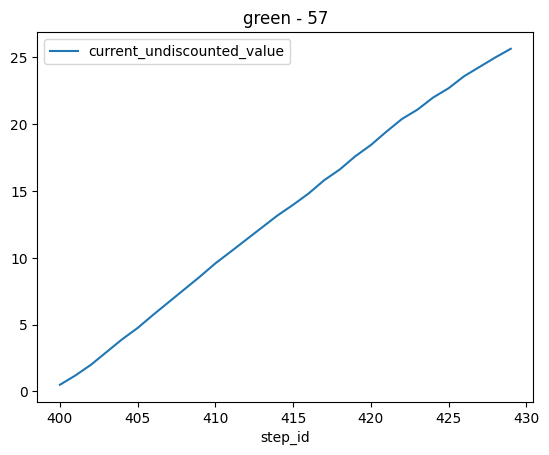

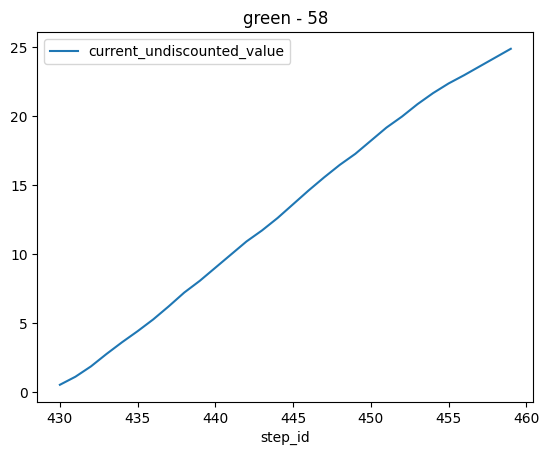

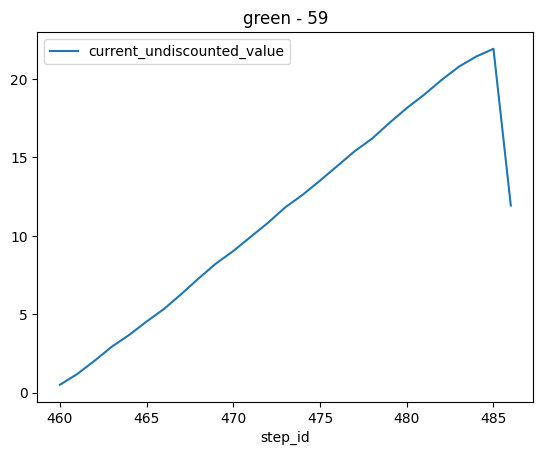

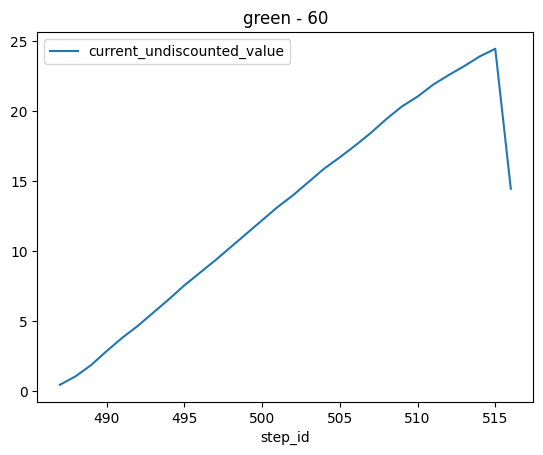

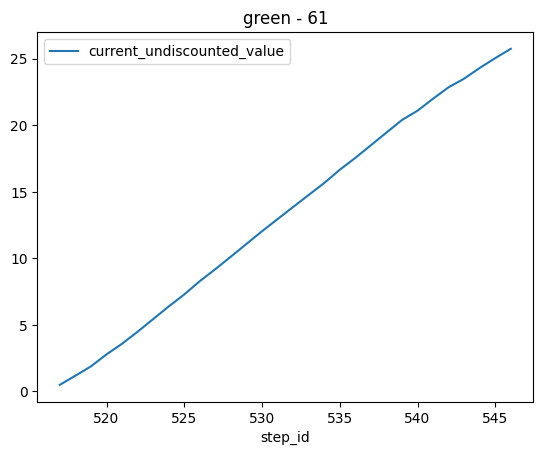

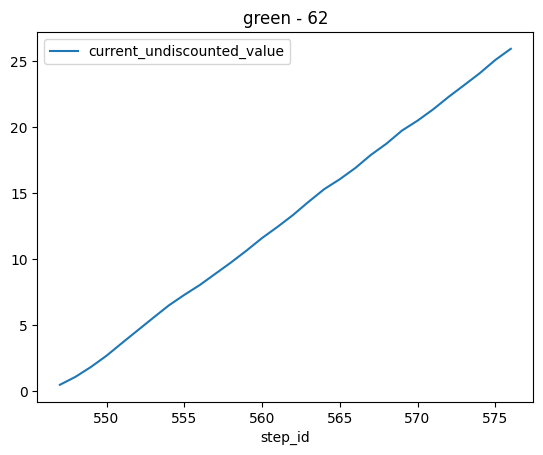

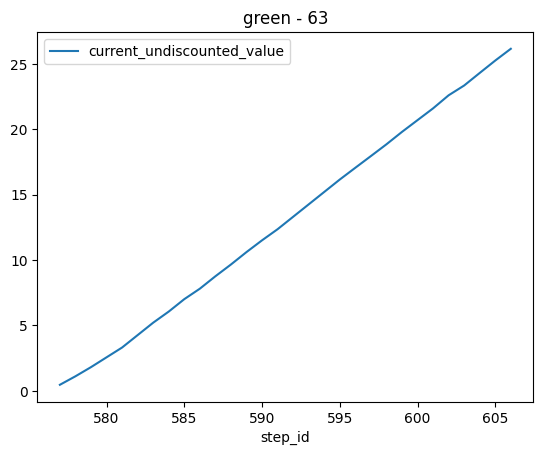

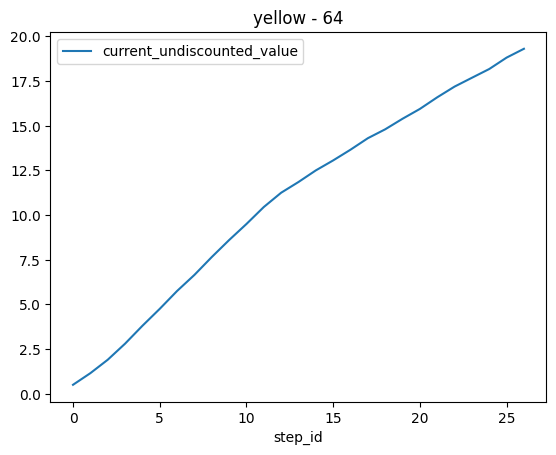

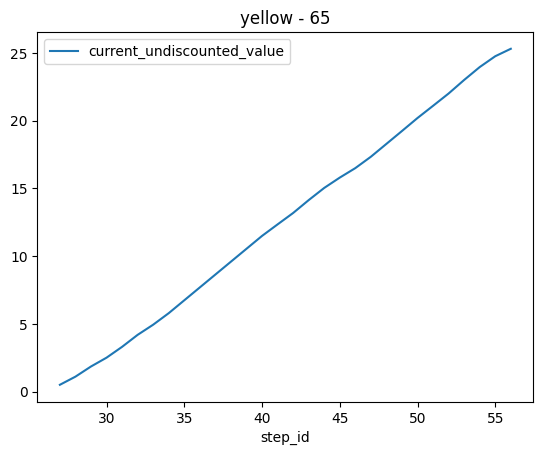

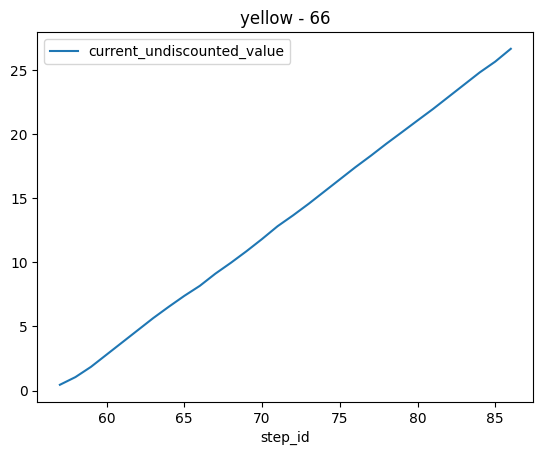

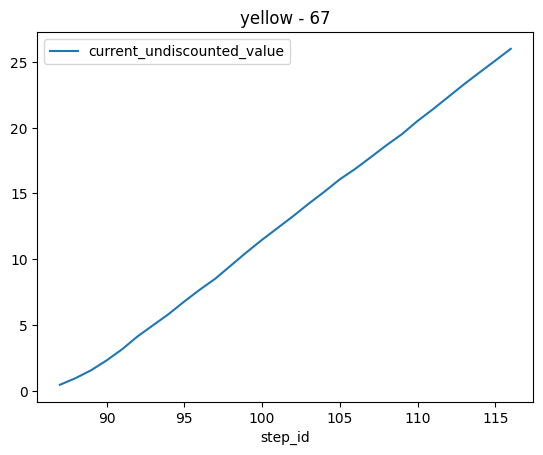

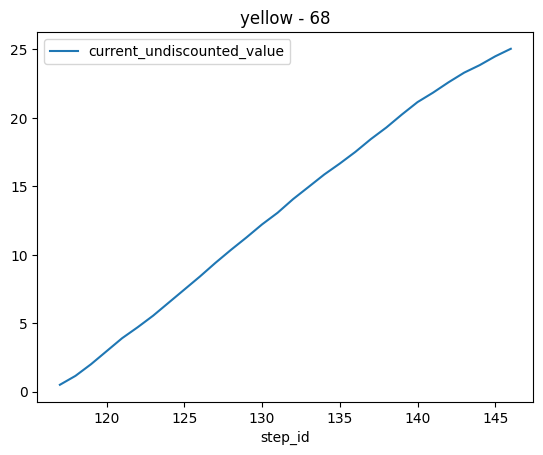

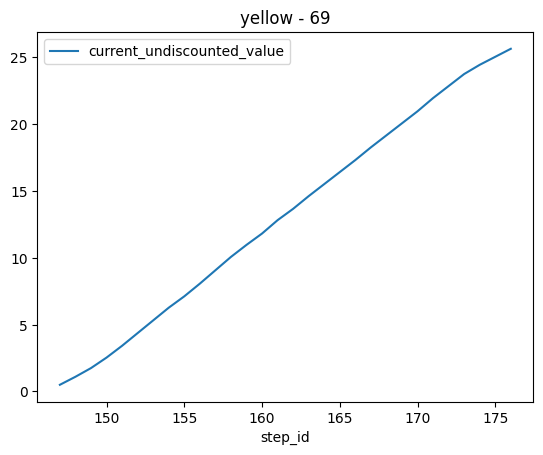

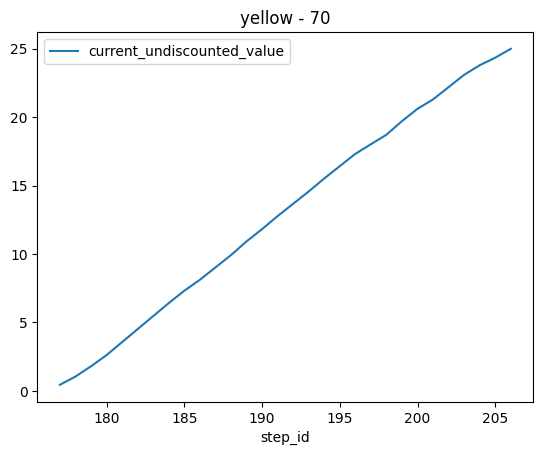

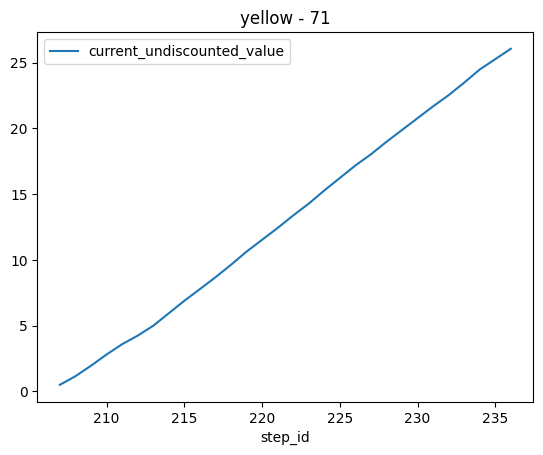

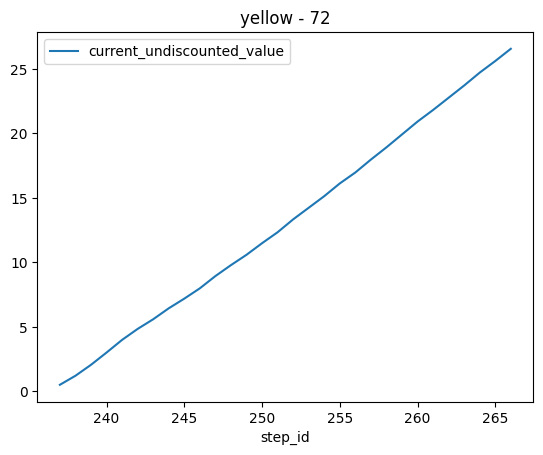

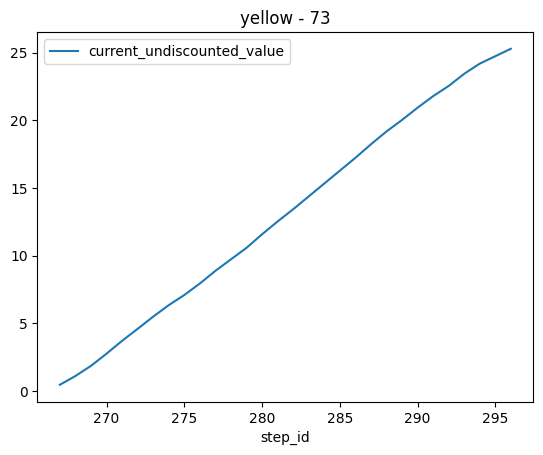

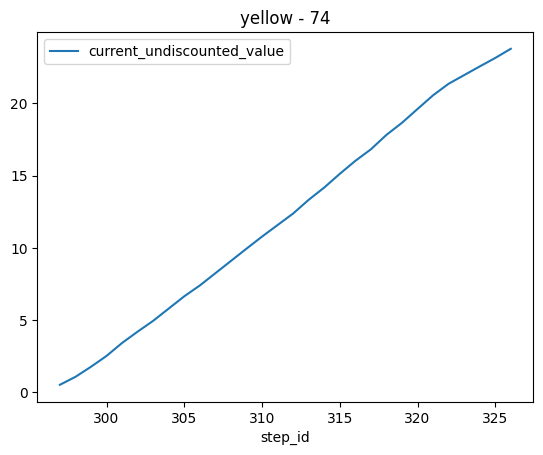

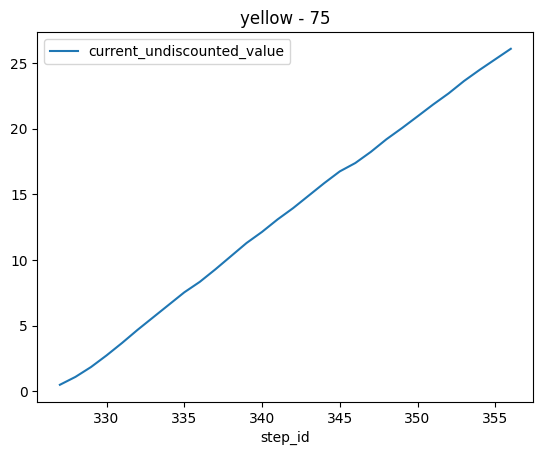

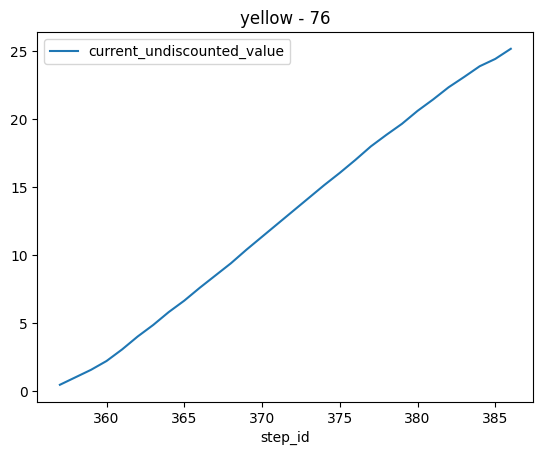

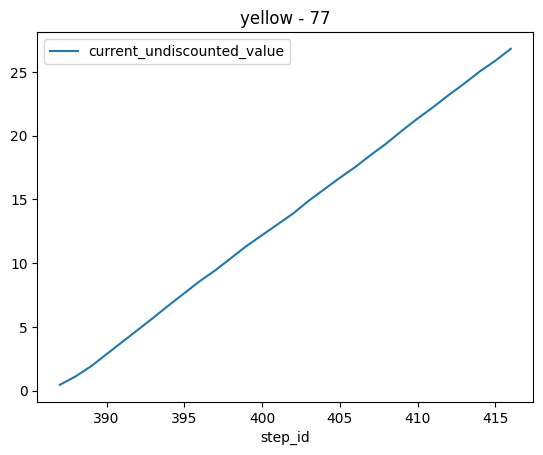

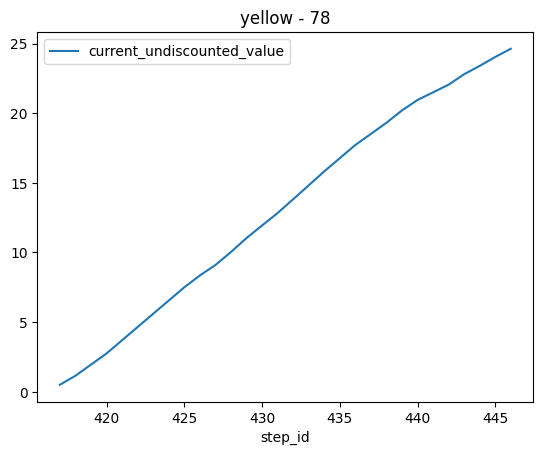

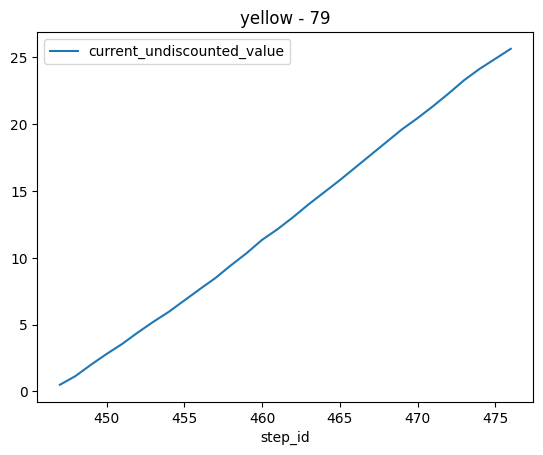

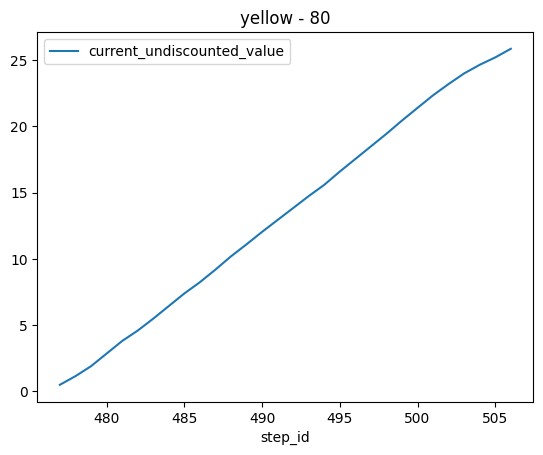

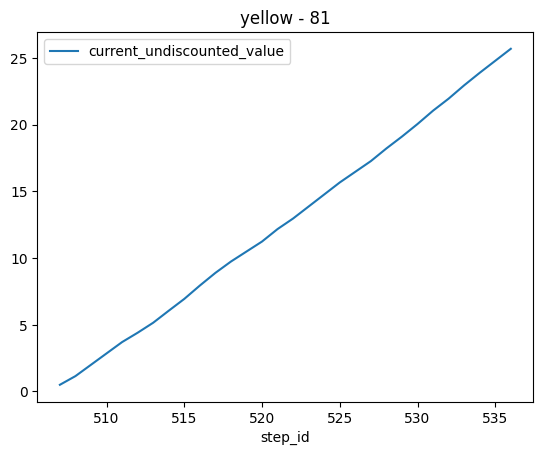

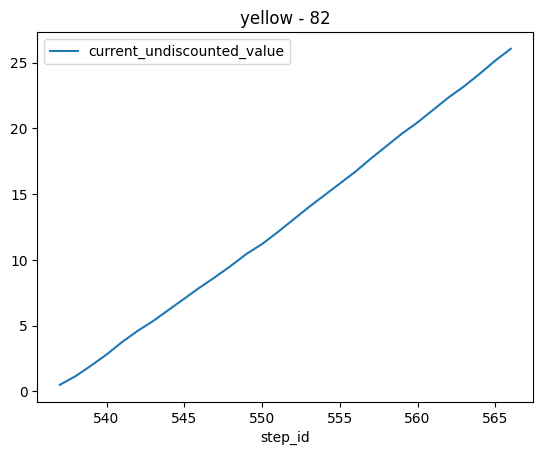

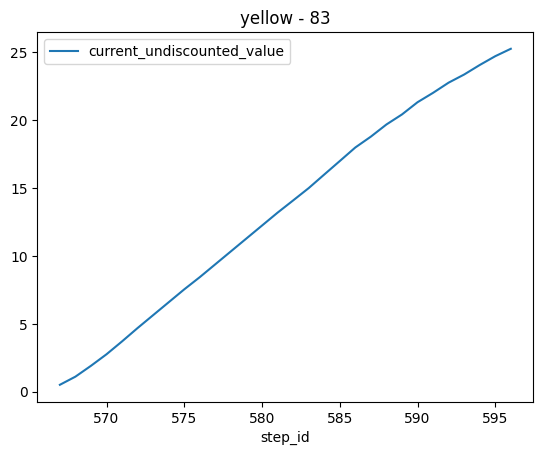

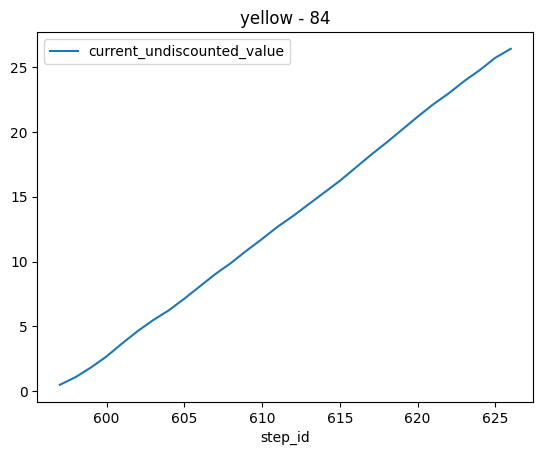

In [896]:
check_df = tmp_df[tmp_df.phase == "eval"]

for iter in check_df.iteration_id.unique():
    t_df = check_df[check_df.iteration_id == iter]
    t_df.plot(x="step_id", y="current_undiscounted_value", title=f"{t_df.task_name.values[0]} - {t_df.iteration_id.values[0]}")

In [897]:
[c for c in check_df.columns]

['task_name',
 'level_0',
 'index',
 'time',
 'running_objective',
 'current_value',
 'current_undiscounted_value',
 'episode_id',
 'iteration_id',
 'step_id',
 'phase',
 'exploration',
 'Linear Velocity [m/s]',
 'Angular Velocity [rad/s]',
 'Image pixel 0',
 'Image pixel 1',
 'Image pixel 2',
 'Image pixel 3',
 'Image pixel 4',
 'Image pixel 5',
 'Image pixel 6',
 'Image pixel 7',
 'Image pixel 8',
 'Image pixel 9',
 'Image pixel 10',
 'Image pixel 11',
 'Image pixel 12',
 'Image pixel 13',
 'Image pixel 14',
 'Image pixel 15',
 'Image pixel 16',
 'Image pixel 17',
 'Image pixel 18',
 'Image pixel 19',
 'Image pixel 20',
 'Image pixel 21',
 'Image pixel 22',
 'Image pixel 23',
 'Image pixel 24',
 'Image pixel 25',
 'Image pixel 26',
 'Image pixel 27',
 'Image pixel 28',
 'Image pixel 29',
 'Image pixel 30',
 'Image pixel 31',
 'Image pixel 32',
 'Image pixel 33',
 'Image pixel 34',
 'Image pixel 35',
 'Image pixel 36',
 'Image pixel 37',
 'Image pixel 38',
 'Image pixel 39',
 'Image p

In [898]:
check_df = tmp_df[tmp_df.phase == "eval"]

t_df = check_df[check_df.iteration_id == 900]

def plot_eval(df, title):
    plt.figure(figsize=(12, 6))
    ax1 = plt.subplot(1, 2, 1)
    ax1.set_ylabel("Accumulated reward")
    df.plot(x="step_id", y="current_undiscounted_value", title=title, ax=ax1)

    ax2 = plt.subplot(2, 2, 2)
    df.plot(x="time", 
            y="Linear Velocity [m/s]", ax=ax2, color="tab:orange", title="Linear velocity")

    ax3 = plt.subplot(2, 2, 4)
    df.plot(x="time", 
            y="Angular Velocity [rad/s]", ax=ax3, color="tab:blue", title="Angular velocity")

    plt.tight_layout()


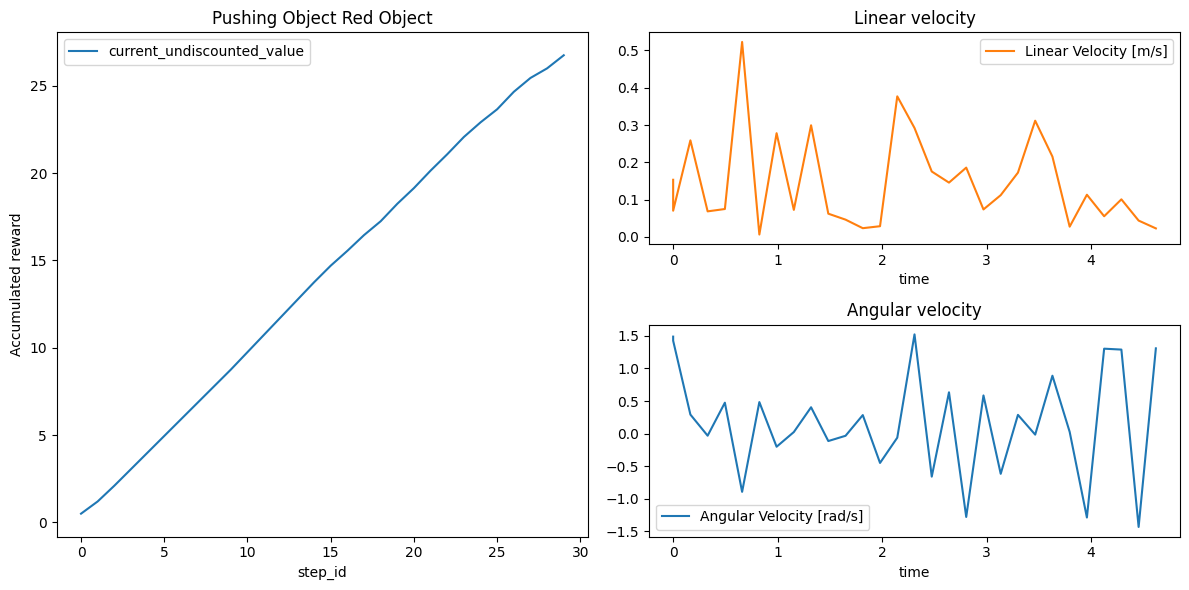

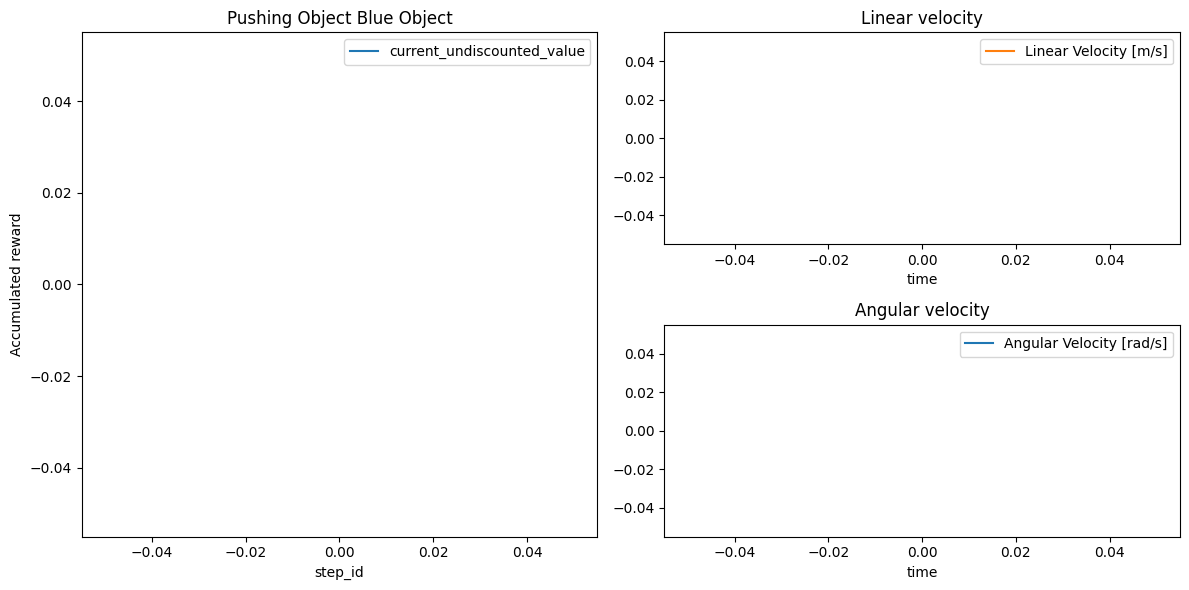

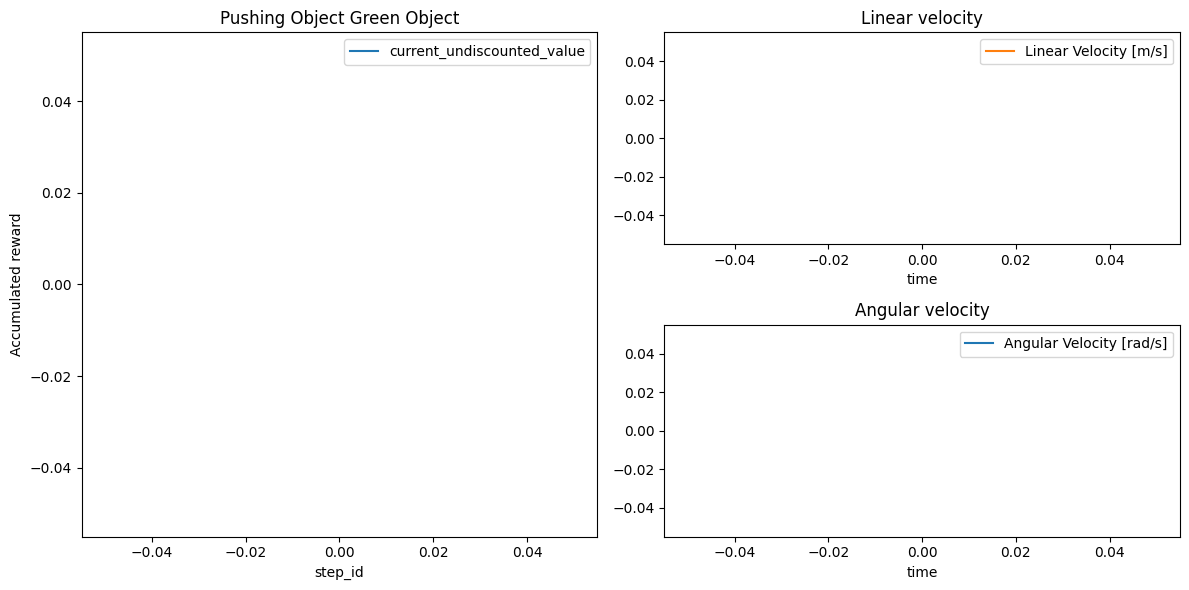

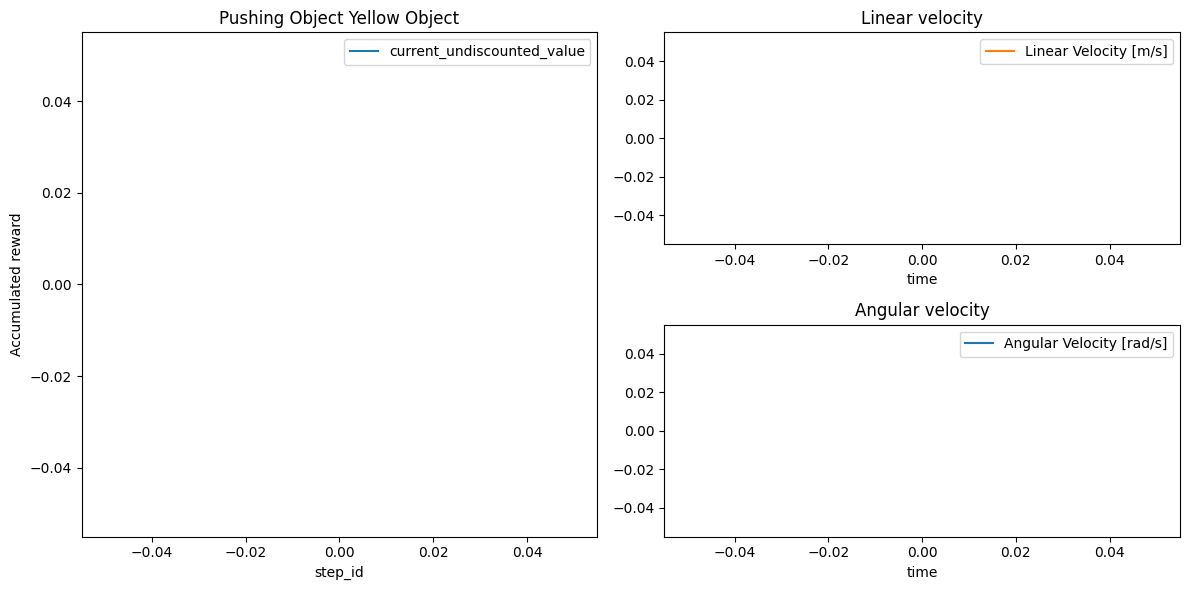

In [899]:
plot_eval(check_df[check_df.iteration_id == 1], title="Pushing Object Red Object")
plot_eval(check_df[check_df.iteration_id == 903], title="Pushing Object Blue Object")
plot_eval(check_df[check_df.iteration_id == 907], title="Pushing Object Green Object")
plot_eval(check_df[check_df.iteration_id == 913], title="Pushing Object Yellow Object")

In [900]:
t_df

,,,task_name,level_0,index,time,running_objective,current_value,current_undiscounted_value,episode_id,iteration_id,step_id,...,Image pixel 1193,Image pixel 1194,Image pixel 1195,Image pixel 1196,Image pixel 1197,Image pixel 1198,Image pixel 1199,is_reset_buffer,learning_starts,catch_the_line
controller,category,buffer_size,,,,,,,,,,,,,,,,,,,,,


In [901]:
check_df

task_name  level_0  index   time  \
controller category      buffer_size                                      
SAC        LineFollowing 16000        circle_red    15981     21  0.000   
                         16000        circle_red    15982     22  0.000   
                         16000        circle_red    15984     23  0.165   
                         16000        circle_red    15985     24  0.330   
                         16000        circle_red    15987     25  0.495   
...                                          ...      ...    ...    ...   
           PushingObject 16000            yellow    18860     25  3.960   
                         16000            yellow    18861     26  4.125   
                         16000            yellow    18862     27  4.290   
                         16000            yellow    18863     28  4.455   
                         16000            yellow    18864     29  4.620   

                                      running_objective current_value  \
controller category      buffer_size                                    
SAC        LineFollowing 16000                 0.489796          None   
                         16000                 0.489796          None   
                         16000                 0.530612          None   
                         16000                 0.571429          None   
                         16000                 0.612245          None   
...                                                 ...           ...   
           PushingObject 16000                 0.850000          None   
                         16000                 0.950000          None   
                         16000                 0.845545          None   
                         16000                 0.950000          None   
                         16000                 0.696133          None   

                                      current_undiscounted_value  episode_id  \
controller category      buffer_size                                           
SAC        LineFollowing 16000                         20.530612           1   
                         16000                         21.020408           1   
                         16000                         21.551020           1   
                         16000                         22.122449           1   
                         16000                         22.734694           1   
...                                                          ...         ...   
           PushingObject 16000                         22.954210           1   
                         16000                         23.904210           1   
                         16000                         24.749754           1   
                         16000                         25.699754           1   
                         16000                         26.395887           1   

                                      iteration_id  step_id  ...  \
controller category      buffer_size                         ...   
SAC        LineFollowing 16000                 716        0  ...   
                         16000                 716        1  ...   
                         16000                 716        2  ...   
                         16000                 716        3  ...   
                         16000                 716        4  ...   
...                                            ...      ...  ...   
           PushingObject 16000                  84      622  ...   
                         16000                  84      623  ...   
                         16000                  84      624  ...   
                         16000                  84      625  ...   
                         16000                  84      626  ...   

                                     Image pixel 1193  Image pixel 1194  \
controller category      buffer_size                                      
SAC        LineFollowing 16000       

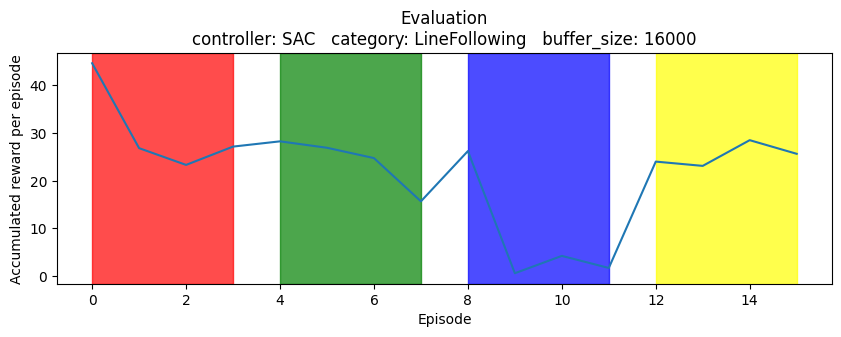

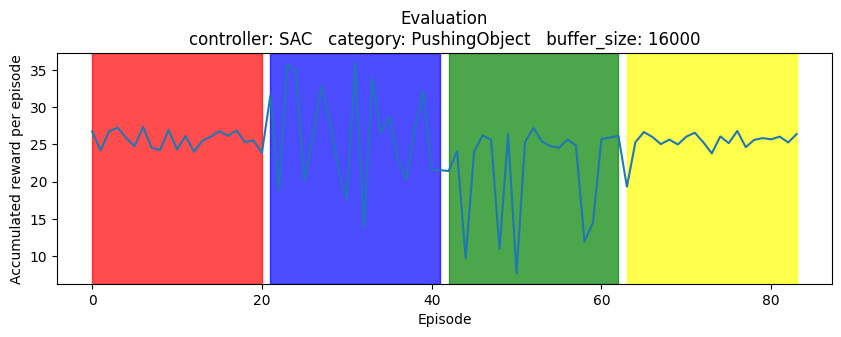

In [902]:
for id in group_df.index:
    plot_learning_curve(id, group_df.index.names, df[df.phase=="eval"], title="Evaluation")

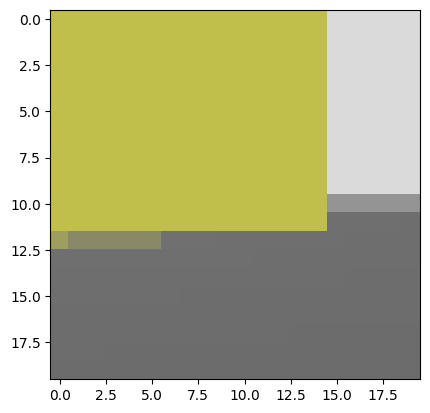

In [903]:
# df = df.reset_index()
pixel_columns = [c for c in df.columns if "pixel" in c.lower()]
chosen_state = np.array(df.loc[:, pixel_columns].iloc[-1])
im = chosen_state.reshape((20, 20, 3))

plt.imshow(im)

In [904]:
# from src.objective import RobotPursuitRunningObjective

# objective_func = RobotPursuitRunningObjective()

# objective_func(state=im, 
#                catcher_pos=[1, 1], 
#                runner_pos=[0, 0], 
#                action=[1, 0], 
#                step_count=0, 
#                max_steps_per_episode=100,
#                runner_collision_thickness=0.49,
#                arena_bounds=[-2.5,2.5,-2.5,2.5],
#                info={})

In [905]:
import numpy as np
np.sum(im)

671.5725

KeyError: ('SAC', 'LineFollowing', False)

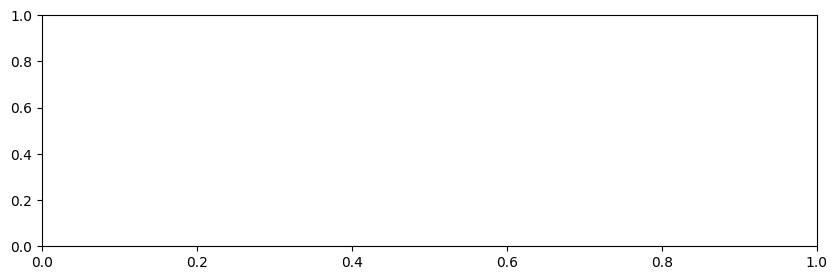

In [906]:
plot_learning_curve(('SAC', 'LineFollowing', False), group_df.index.names, df)
plot_learning_curve(('SAC', 'LineFollowing', True), group_df.index.names, df)

In [ ]:
tmp_df["previous_step"] = [tmp_df.step_id.values.tolist()[0]] + tmp_df.step_id.values.tolist()[:-1]
tmp_df[(tmp_df.step_id.diff() < 0)]
# tmp_df.step_id.values.tolist()[1:]+ [tmp_df.step_id.values.tolist()[-1]]

/tmp/ipykernel_127043/3476527340.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp_df["previous_step"] = [tmp_df.step_id.values.tolist()[0]] + tmp_df.step_id.values.tolist()[:-1]


index   time  running_objective  \
controller category      is_reset_buffer                                    
SAC        LineFollowing False                6  0.000           0.408163   
                         False                8  0.198           0.000000   
                         False                9  0.363           0.000000   
                         False               10  0.528           0.000000   
                         False               11  0.693           0.000000   
                         False                2  0.000           0.693878   
                         False               15  0.000           0.734694   
                         False               18  0.363           0.979592   
                         False               19  0.528           0.979592   
                         False               20  0.693           0.897959   
                         False               21  0.858           0.775510   
                         False               22  1.023           0.530612   
                         False               23  1.188           0.285714   
                         False               24  1.353           0.081633   
                         False               25  1.518           0.040816   
                         False               26  1.683          -1.000000   
                         False                0  0.000           0.530612   

                                         current_value  \
controller category      is_reset_buffer                 
SAC        LineFollowing False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   

                                          current_undiscounted_value  \
controller category      is_reset_buffer                               
SAC        LineFollowing False                              2.693878   
                         False                              2.857143   
                         False                              2.857143   
                         False                              2.857143   
                         False                              2.857143   
                         False                              2.122449   
                         False                              5.755102   
                         False                              8.448980   
                         False                              9.428571   
                         False                             10.326531   
                         False                             11.102041   
                         False                             11.632653   
                         False                             11.918367   
                         False                             12.000000   
                         False                             12.040816   
                         False                             11.040816   
                         False                              0.530612   

                                          episode_id  iteration_id  \
controller category      is_reset_bu

In [ ]:
tmp_df[tmp_df.iteration_id == 1196]

index   time  running_objective  \
controller category      is_reset_buffer                                    
SAC        LineFollowing False                0  0.000           0.693878   
                         False                1  0.000           0.857143   
                         False               15  0.000           0.734694   
                         False               16  0.000           0.775510   
                         False               17  0.165           0.938776   
                         False                2  0.198           0.979592   
                         False                3  0.363           0.775510   
                         False               18  0.363           0.979592   
                         False                4  0.528           0.408163   
                         False               19  0.528           0.979592   
                         False                5  0.693           0.448980   
                         False               20  0.693           0.897959   
                         False                6  0.858           0.326531   
                         False               21  0.858           0.775510   
                         False                7  1.023           0.122449   
                         False               22  1.023           0.530612   
                         False                8  1.188           0.040816   
                         False               23  1.188           0.285714   
                         False                9  1.353           0.040816   
                         False               24  1.353           0.081633   
                         False               10  1.518           0.040816   
                         False               25  1.518           0.040816   
                         False               11  1.683           0.000000   
                         False               26  1.683          -1.000000   
                         False               12  1.848           0.081633   
                         False               13  2.013           0.081633   
                         False               14  2.178           0.122449   

                                         current_value  \
controller category      is_reset_buffer                 
SAC        LineFollowing False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   

                                          current_undiscounted_value  \
controller category      is_reset_buffer             